# Recommendation System for Amazon Musical Instruments

**Data Mining Homework3 — YZM2022**

Bu çalışmada Amazon Reviews 2023 verisinin Musical Instruments kategorisi üzerinde recommendation system geliştirildi. Üç ana yaklaşımı (content-based, collaborative, hybrid) karşılaştırıldı, üç farklı feature selection tekniği uyguladık ve sonuçları 5-fold cross validation ile doğruladık.

## Çalışmanın Özeti

- **Dataset:** Amazon Reviews 2023 Musical Instruments, 5-core filtreleme sonrası 222,276 etkileşim, 25,746 kullanıcı, 13,575 ürün
- **Modeller:** TF-IDF, Sentence-BERT, CLIP, User-based CF, Item-based CF, SVD, ALS, Weighted Hybrid, Multimodal Ensemble
- **Feature Selection:** Chi-square, Mutual Information, ReliefF
- **Evaluation:** 5-fold cross validation; P@K, R@K, NDCG@K, MAP@K, Coverage, MAE, RMSE
- **Cold-start analysis:** 1-review ve 2-review kullanıcılar için ayrı değerlendirme

## İçerik

1. Giriş
2. Dataset
3. Exploratory Data Analysis
4. Recommendation Models
5. Evaluation
6. Discussion


# 1. Giriş

Recommendation system'ler, kullanıcılara büyük ürün havuzları içinden ilgilenebilecekleri öğeleri öneren makine öğrenmesi sistemleridir. Amazon, Netflix, Spotify gibi platformların temel bileşenidir.

Bu çalışmada Amazon Reviews 2023 verisinin **Musical Instruments** kategorisi üzerinde farklı recommendation yaklaşımlarını karşılaştırdık. Musical instruments kategorisini seçme nedenimiz:
- Sparsity oranı yüksek (%99.94)
- Hem metin (ürün açıklamaları, yorumlar) hem görsel (ürün fotoğrafları) içerik mevcut
- Literatürde daha az çalışılmış bir kategori

## 1.1 Problem Tanımı

Bir kullanıcının geçmiş rating'lerine ve yorumlarına bakarak, daha önce etkileşime girmediği ürünler arasından **top-K öneri listesi** üretmek istiyoruz. Sistemin çözmesi gereken üç temel zorluk:

1. **Sparsity:** Kullanıcı-ürün matrisinin %99.94'ünden fazlası boş.
- Yani devasa bir müzik mağazası düşünün; her birimiz on binlerce üründen sadece birkaç tanesine dokunuyoruz, geri kalan tüm raflar bizim profilimizde tamamen boş/bilinmez olarak kalıyor.


2. **Cold-start:** Yeni kullanıcılar veya az rating'i olan ürünler için yeterli veri yok.
- Tıpkı dükkandan içeri yeni girmiş ve henüz hiçbir şeye bakmamış bir müşteriye ne önereceğimizi bilememe problemi gibi.


3. **Diversity vs Accuracy:** Sadece popüler ürün önermek doğruluğu artırır ama keşfi azaltır.


## 1.2 Yaklaşımımız

Üç ana paradigmayı kurup karşılaştırdık:

- **Content-Based Filtering:** Ürünlerin metin (TF-IDF, Sentence-BERT) ve görsel (CLIP) içeriğine bakarak benzerlik bulur.
- Özetle: "Sen daha önce bu marka ahşap bir klasik gitar almıştın, bak burada yapısal olarak ona çok benzeyen başka gitarlar var" mantığıdır.
- **Collaborative Filtering:** Kullanıcıların etkileşim örüntülerinden öğrenir.
- Özetle: "Seninle geçmişte tamamen aynı gitar tellerini ve penaları satın almış bir başka müşteri, şu amfiyi de çok sevdi; senin de hoşuna gidebilir" diyerek kalabalıktan öğrenme yöntemidir.
- **Hybrid:** Yukarıdaki iki yaklaşımı birleştirir.

Ek olarak, kullanıcı yorumlarındaki sentiment bilgisini rating'le birleştiren bir **sentiment-weighted rating** denedik.


# 2. Dataset

## 2.1 Veri Kaynağı

[McAuley-Lab Amazon Reviews 2023](https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023) verisinin Musical Instruments alt kümesini kullandık. Orijinal veri 1999-2023 arasını kapsar ve yaklaşık 3 milyon etkileşim içerir. Her etkileşimde user_id, parent_asin, rating (1-5), yorum metni, tarih, verified_purchase ve helpful_vote bilgisi mevcut. Ürün metadata'sında title, description, features, categories, store ve görsel URL'leri var.

## 2.2 Sampling Stratejisi

Veriyi makul sürede işleyebilmek ve daha kaliteli bir alt küme elde etmek için şu adımları uyguladık:

1. **Tarih filtresi:** 2018-01-01 ile 2023-09-12 arası seçildi. Modern mobil-sonrası dönemi yansıtıyor.
2. **Cold-start test seti ayrımı:** 1-2 review'ı olan kullanıcılardan 5,000 tanesi, 5-core filtreleme uygulanmadan ÖNCE ayrıldı. Bunlar daha sonra cold-start değerlendirmesinde kullanıldı.
3. **İteratif 5-core filtreleme:** Her kullanıcının ≥5 ürünle, her ürünün ≥5 kullanıcıyla etkileşimi olacak şekilde filtreyi tekrar tekrar uyguladık.
4. **Tekrarlanabilirlik:** Tüm rastgele işlemlerde seed=42 kullanıldı.

Hazırladığımız veri Hugging Face Hub'a yüklendi: `oyku-tugana/amazon-musical-instruments-2018-2023-5core`

## 2.3 Setup ve Veri Yükleme


In [1]:
# Temel kutuphaneler
import os, pickle, time, json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix, load_npz
from scipy.stats import spearmanr
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize as sk_normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import chi2, mutual_info_classif, SelectKBest
from sklearn.model_selection import KFold
import implicit

import nltk
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from huggingface_hub import hf_hub_download
from scipy.sparse import vstack as sparse_vstack

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Project root'u otomatik bul
# results/embeddings/ klasoru hangi parent'ta bulunursa orasini root say.
_cwd = Path('.').resolve()
PROJECT_ROOT = _cwd
_search = _cwd
for _ in range(3):  # en fazla 3 seviye yukari bak
    if (_search / 'results' / 'embeddings').is_dir():
        PROJECT_ROOT = _search
        break
    if _search.parent == _search:
        break
    _search = _search.parent

print(f'Project root: {PROJECT_ROOT}')

DATA_DIR     = PROJECT_ROOT / 'data'
RESULTS_DIR  = PROJECT_ROOT / 'results'
FIGURES_DIR  = RESULTS_DIR / 'figures'
TABLES_DIR   = RESULTS_DIR / 'tables'
EMBEDDINGS_DIR = RESULTS_DIR / 'embeddings'
CACHE_DIR    = DATA_DIR / 'cache'

for d in [DATA_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR, EMBEDDINGS_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

HF_DATASET_REPO = 'oyku-tugana/amazon-musical-instruments-2018-2023-5core'

SEED = 42
K_VALUES = [5, 10, 20]
N_FOLDS = 5
TEST_MONTHS = 12
TFIDF_MAX_FEATURES = 5000
SBERT_MODEL = 'all-MiniLM-L6-v2'
CLIP_MODEL  = 'openai/clip-vit-base-patch32'

np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'

# NLTK stopwords
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords', quiet=True)

print(f'Setup complete. Seed={SEED}, K_VALUES={K_VALUES}, N_FOLDS={N_FOLDS}')


Project root: /Users/toyku/PycharmProjects/TuganaOyku_Yildiz_24018020
Setup complete. Seed=42, K_VALUES=[5, 10, 20], N_FOLDS=5


In [2]:
# ===================================================================
# Yardimci fonksiyonlar
# ===================================================================

# --- data_utils ---
_PARQUET_PATHS = {
    'interactions': 'interactions/train-00000-of-00001.parquet',
    'cold_start':   'cold_start/train-00000-of-00001.parquet',
    'items':        'items/train-00000-of-00001.parquet',
}

def _download_parquet(key):
    return hf_hub_download(
        repo_id=HF_DATASET_REPO, filename=_PARQUET_PATHS[key],
        repo_type='dataset', cache_dir=str(CACHE_DIR))

def load_interactions():
    df = pd.read_parquet(_download_parquet('interactions'))
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    return df

def load_cold_start():
    df = pd.read_parquet(_download_parquet('cold_start'))
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    return df

def load_items():
    return pd.read_parquet(_download_parquet('items'))

def load_all():
    return load_interactions(), load_cold_start(), load_items()


# --- splits ---
def temporal_split(df, test_months=3, time_col='date'):
    cutoff = df[time_col].max() - pd.Timedelta(days=test_months * 30)
    train = df[df[time_col] <= cutoff].copy()
    test  = df[df[time_col] >  cutoff].copy()
    return train, test

def leave_one_out_per_user(df, user_col='user_id', time_col='timestamp'):
    df_sorted = df.sort_values([user_col, time_col])
    test_idx = df_sorted.groupby(user_col).tail(1).index
    train = df_sorted.drop(test_idx)
    test  = df_sorted.loc[test_idx]
    return train, test


# --- sentiment ---
_sentiment_analyzer = SentimentIntensityAnalyzer()

def compute_sentiment(text):
    if not isinstance(text, str) or len(text) < 5:
        return np.nan
    return _sentiment_analyzer.polarity_scores(text)['compound']

def sentiment_to_rating_scale(s):
    return 3 + s * 2

def add_sentiment_columns(df, text_col='review_text', rating_col='rating', alpha=0.7):
    df = df.copy()
    df['sentiment'] = df[text_col].apply(compute_sentiment)
    sent_as_rating = df['sentiment'].apply(
        lambda s: sentiment_to_rating_scale(s) if pd.notna(s) else np.nan)
    df['adjusted_rating'] = np.where(
        df['sentiment'].notna(),
        alpha * df[rating_col] + (1 - alpha) * sent_as_rating,
        df[rating_col])
    return df


# --- metrics ---
def precision_at_k(recommended, relevant, k):
    if k == 0: return 0.0
    top_k = recommended[:k]
    hits = sum(1 for item in top_k if item in relevant)
    return hits / k

def recall_at_k(recommended, relevant, k):
    if not relevant: return 0.0
    top_k = recommended[:k]
    hits = sum(1 for item in top_k if item in relevant)
    return hits / len(relevant)

def ndcg_at_k(recommended, relevant, k):
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            dcg += 1.0 / np.log2(i + 2)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def average_precision_at_k(recommended, relevant, k):
    if not relevant: return 0.0
    score, hits = 0.0, 0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k)

def coverage(all_recommended_items, all_items):
    return len(set(all_recommended_items)) / len(all_items)

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def evaluate_topk(recs_dict, ground_truth_dict, k_values=(5, 10, 20), all_items=None):
    results = {}
    for k in k_values:
        results[f'P@{k}']    = []
        results[f'R@{k}']    = []
        results[f'NDCG@{k}'] = []
        results[f'MAP@{k}']  = []
    for user, gt in ground_truth_dict.items():
        if user not in recs_dict: continue
        recs = recs_dict[user]
        for k in k_values:
            results[f'P@{k}'].append(precision_at_k(recs, gt, k))
            results[f'R@{k}'].append(recall_at_k(recs, gt, k))
            results[f'NDCG@{k}'].append(ndcg_at_k(recs, gt, k))
            results[f'MAP@{k}'].append(average_precision_at_k(recs, gt, k))
    aggregated = {key: float(np.mean(vals)) if vals else 0.0
                  for key, vals in results.items()}
    if all_items is not None:
        all_recommended = [item for recs in recs_dict.values() for item in recs]
        aggregated['Coverage'] = coverage(all_recommended, all_items)
    return aggregated


# --- cv ---
def random_kfold_split(df, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(df)):
        yield fold_idx, df.iloc[train_idx].copy(), df.iloc[test_idx].copy()


def aggregate_fold_metrics(fold_metrics_list):
    if not fold_metrics_list: return {}
    keys = set()
    for fm in fold_metrics_list:
        keys.update(fm.keys())
    aggregated = {}
    for k in keys:
        values = [fm[k] for fm in fold_metrics_list if k in fm]
        if values:
            aggregated[k] = {
                'mean':   float(np.mean(values)),
                'std':    float(np.std(values)),
                'values': [float(v) for v in values],
            }
    return aggregated

print('Yardimci fonksiyonlar yuklendi: data_utils, splits, sentiment, metrics, cv')


Yardimci fonksiyonlar yuklendi: data_utils, splits, sentiment, metrics, cv


In [3]:
# HuggingFace'ten ana etkilesim verisi, cold-start ayrik kume ve urun metadata'si yuklenir
interactions, cold_start, items = load_all()

print(f'Main interactions: {interactions.shape}')
print(f'Cold-start set:    {cold_start.shape}')
print(f'Items metadata:    {items.shape}')

Main interactions: (222276, 9)
Cold-start set:    (3299, 9)
Items metadata:    (13575, 14)


In [4]:
# Dataset ozet istatistikleri
n_users = interactions['user_id'].nunique()
n_items = interactions['parent_asin'].nunique()
sparsity = 1 - len(interactions) / (n_users * n_items)

print('=== DATASET OZET ===\n')
print(f'Toplam etkilesim:        {len(interactions):,}')
print(f'Tekil kullanici:         {n_users:,}')
print(f'Tekil urun:              {n_items:,}')
print(f'Sparsity:                {sparsity:.6f} ({sparsity*100:.4f}%)')
print(f'Ortalama rating:         {interactions["rating"].mean():.3f}')
print(f'Verified purchase orani: {interactions["verified_purchase"].mean()*100:.1f}%')
print(f'Tarih araligi:           {interactions["date"].min().date()} -> {interactions["date"].max().date()}')
print()
print(f'Cold-start kullanici:    {cold_start["user_id"].nunique():,}')
print(f'Cold-start etkilesim:    {len(cold_start):,}')
print()
print(f'Gorsel olan urun:        {items["has_image"].sum():,} ({items["has_image"].mean()*100:.1f}%)')
print(f'Aciklamasi olan urun:    {items["has_description"].sum():,} ({items["has_description"].mean()*100:.1f}%)')
print(f'Fiyati olan urun:        {items["has_price"].sum():,} ({items["has_price"].mean()*100:.1f}%)')

=== DATASET OZET ===

Toplam etkilesim:        222,276
Tekil kullanici:         25,746
Tekil urun:              13,575
Sparsity:                0.999364 (99.9364%)
Ortalama rating:         4.451
Verified purchase orani: 89.1%
Tarih araligi:           2018-01-01 -> 2023-09-06

Cold-start kullanici:    2,991
Cold-start etkilesim:    3,299

Gorsel olan urun:        13,572 (100.0%)
Aciklamasi olan urun:    8,357 (61.6%)
Fiyati olan urun:        10,560 (77.8%)


# 3. Exploratory Data Analysis

Veriyi dört açıdan inceledik: kullanıcı davranışları, ürün özellikleri, zamansal örüntüler ve metin/sentiment.

## 3.1 User Analysis

Kullanıcıların ne kadar aktif olduğunu, hangi rating'leri verdiklerini ve "power user" denilen yoğun katkı verenleri inceledik.


In [5]:
# Kullanici seviyesinde istatistikler
user_stats = interactions.groupby('user_id').agg(
    n_reviews=('rating', 'count'),
    mean_rating=('rating', 'mean'),
    rating_std=('rating', 'std'),
).reset_index()

print('Kullanici seviyesinde istatistikler:')
print(user_stats[['n_reviews', 'mean_rating', 'rating_std']].describe().round(3))

# Power user tanimi: top %5
power_threshold = user_stats['n_reviews'].quantile(0.95)
n_power = (user_stats['n_reviews'] >= power_threshold).sum()
print(f'\nPower user threshold (top %5): >= {power_threshold:.0f} review')
print(f'Power user sayisi: {n_power:,} ({n_power/len(user_stats)*100:.1f}%)')

Kullanici seviyesinde istatistikler:
       n_reviews  mean_rating  rating_std
count  25746.000    25746.000   25746.000
mean       8.633        4.440       0.742
std        6.909        0.621       0.624
min        5.000        1.000       0.000
25%        5.000        4.167       0.000
50%        7.000        4.600       0.675
75%        9.000        5.000       1.265
max      239.000        5.000       2.191

Power user threshold (top %5): >= 19 review
Power user sayisi: 1,382 (5.4%)


In [6]:
# Power user'lar toplam review'larin yuzde kacini olusturuyor
power_users = user_stats[user_stats['n_reviews'] >= power_threshold]
power_review_share = power_users['n_reviews'].sum() / user_stats['n_reviews'].sum()
print(f'Power user\'larin toplam review icindeki payi: {power_review_share*100:.1f}%')

# Power vs ordinary rating davranisi
ordinary_users = user_stats[user_stats['n_reviews'] < power_threshold]
print(f'\nOrtalama rating:')
print(f'  Power users:    {power_users["mean_rating"].mean():.3f}')
print(f'  Ordinary users: {ordinary_users["mean_rating"].mean():.3f}')
print(f'\nRating standart sapmasi:')
print(f'  Power users:    {power_users["rating_std"].mean():.3f}')
print(f'  Ordinary users: {ordinary_users["rating_std"].mean():.3f}')

Power user'larin toplam review icindeki payi: 18.3%

Ortalama rating:
  Power users:    4.468
  Ordinary users: 4.438

Rating standart sapmasi:
  Power users:    0.811
  Ordinary users: 0.738


**Yorum:** Kullanıcı dağılımı uzun kuyruklu — top %5 kullanıcı toplam etkileşimlerin önemli bir kısmını oluşturuyor (Pareto benzeri). Bu power user'lar daha düşük ortalama rating veriyor (daha eleştirel) ve daha yüksek varyans gösteriyor (daha çeşitli görüşler).


## 3.2 Item Analysis

Ürünlerin kategori dağılımına, popülerlik örüntüsüne ve metadata zenginliğine baktık.


In [7]:
# Item seviyesinde istatistikler
item_stats = interactions.groupby('parent_asin').agg(
    n_reviews=('rating', 'count'),
    mean_rating=('rating', 'mean'),
).reset_index()

items_full = items.merge(item_stats, on='parent_asin', how='left')

print('Urun seviyesinde istatistikler:')
print(items_full[['n_reviews', 'mean_rating']].describe().round(3))

Urun seviyesinde istatistikler:
       n_reviews  mean_rating
count  13575.000    13575.000
mean      16.374        4.415
std       32.556        0.499
min        5.000        1.000
25%        6.000        4.188
50%        9.000        4.500
75%       16.000        4.789
max     1456.000        5.000


In [8]:
# Kategori cikartma: son seviyeyi al ('Musical Instruments > Guitars > Electric Guitars' -> 'Electric Guitars')
def get_top_category(cat):
    if pd.isna(cat) or cat == '':
        return None
    parts = [p.strip() for p in cat.split('>')]
    return parts[-1] if parts else None

items_full['top_category'] = items_full['categories'].apply(get_top_category)
cat_counts = items_full['top_category'].value_counts().head(15)

print('Top 15 alt kategori (urun sayisi):\n')
for cat, n in cat_counts.items():
    print(f'  {n:>5} urun  -  {cat}')
print(f'\nTekil alt kategori: {items_full["top_category"].nunique()}')

Top 15 alt kategori (urun sayisi):

    451 urun  -  Stands
    448 urun  -  Straps
    391 urun  -  Instrument Cables
    358 urun  -  Picks
    344 urun  -  Pickups & Pickup Covers
    324 urun  -  Tools
    317 urun  -  Microphone Cables
    312 urun  -  Distortion & Overdrive
    253 urun  -  Bridges & Bridge Parts
    231 urun  -  Electronics
    214 urun  -  Solid Body
    209 urun  -  Knobs
    207 urun  -  Stage Lights
    205 urun  -  Wireless Lavalier Microphones
    190 urun  -  Tuning Pegs

Tekil alt kategori: 365


## 3.3 Temporal Analysis

Etkileşimlerin zaman içindeki dağılımına, mevsimsellik etkisine ve COVID-19 döneminin yansımasına baktık.


In [9]:
# Yillik ve aylik trend
interactions['year']  = interactions['date'].dt.year
interactions['month'] = interactions['date'].dt.month

yearly = interactions.groupby('year').size()
print('Yillara gore review sayisi:')
print(yearly.to_string())

# COVID-19 oncesi ve sonrasi karsilastirmasi
covid_start = pd.Timestamp('2020-03-01')
pre_covid    = interactions[interactions['date'] < covid_start]
during_covid = interactions[(interactions['date'] >= covid_start) & (interactions['date'] < pd.Timestamp('2022-01-01'))]
post_covid   = interactions[interactions['date'] >= pd.Timestamp('2022-01-01')]

print(f'\nCOVID-19 oncesi (< 2020-03):       {len(pre_covid):,} review,  rating={pre_covid["rating"].mean():.3f}')
print(f'COVID-19 donemi (2020-03..2022-01): {len(during_covid):,} review,  rating={during_covid["rating"].mean():.3f}')
print(f'COVID-19 sonrasi (>= 2022-01):     {len(post_covid):,} review,  rating={post_covid["rating"].mean():.3f}')

Yillara gore review sayisi:
year
2018    31453
2019    44563
2020    43355
2021    45665
2022    42160
2023    15080

COVID-19 oncesi (< 2020-03):       85,959 review,  rating=4.499
COVID-19 donemi (2020-03..2022-01): 79,077 review,  rating=4.438
COVID-19 sonrasi (>= 2022-01):     57,240 review,  rating=4.397


**Gözlem:** 2023 ortasından itibaren aylık review sayısı hızla düşüyor (700'den 6'ya). Bunun nedeni veri toplama yöntemi — snapshot tarihine yakın review'lar henüz tam toplanmamış. Bu nedenle **son 12 ayı** test seti olarak kullandık.

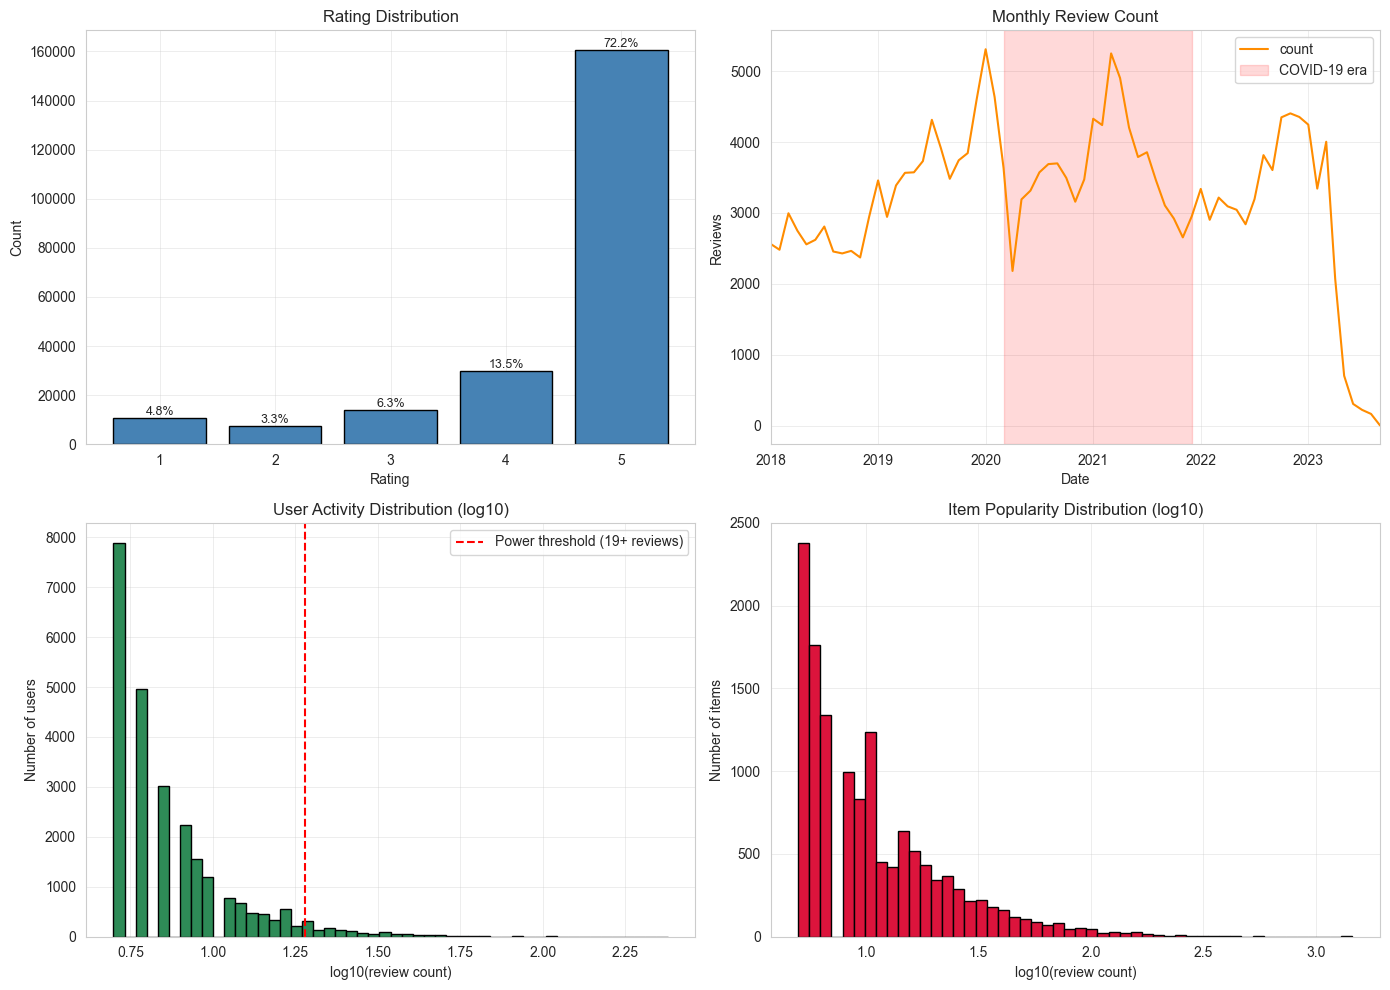

In [10]:
# 4-panel EDA gorseli
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Rating dagilimi
rating_counts = interactions['rating'].value_counts().sort_index()
axes[0,0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
axes[0,0].set_title('Rating Distribution', fontsize=12)
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')
for x, y in zip(rating_counts.index, rating_counts.values):
    axes[0,0].text(x, y, f'{y/len(interactions)*100:.1f}%', ha='center', va='bottom', fontsize=9)

# Panel 2: Aylik trend
monthly = interactions['date'].dt.to_period('M').value_counts().sort_index()
monthly.plot(ax=axes[0,1], color='darkorange', lw=1.5)
axes[0,1].set_title('Monthly Review Count', fontsize=12)
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Reviews')
axes[0,1].axvspan(pd.Period('2020-03'), pd.Period('2021-12'), alpha=0.15, color='red', label='COVID-19 era')
axes[0,1].legend()

# Panel 3: Kullanici review sayisi dagilimi (log scale)
user_counts = interactions['user_id'].value_counts()
axes[1,0].hist(np.log10(user_counts.values), bins=50, color='seagreen', edgecolor='black')
axes[1,0].axvline(np.log10(power_threshold), color='red', linestyle='--',
                   label=f'Power threshold ({power_threshold:.0f}+ reviews)')
axes[1,0].set_title('User Activity Distribution (log10)', fontsize=12)
axes[1,0].set_xlabel('log10(review count)')
axes[1,0].set_ylabel('Number of users')
axes[1,0].legend()

# Panel 4: Item popularity dagilimi (log scale)
i_counts = interactions['parent_asin'].value_counts()
axes[1,1].hist(np.log10(i_counts.values), bins=50, color='crimson', edgecolor='black')
axes[1,1].set_title('Item Popularity Distribution (log10)', fontsize=12)
axes[1,1].set_xlabel('log10(review count)')
axes[1,1].set_ylabel('Number of items')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_overview.png', dpi=100)
plt.show()

## 3.4 Text Analysis

Kullanıcı yorumlarındaki uzunluk dağılımına, sık kullanılan kelimelere ve sentiment'a baktık.


In [11]:
# Review uzunluklarinin dagilimi
interactions['review_length'] = interactions['review_text'].fillna('').str.len()
print('Review uzunluk istatistikleri (karakter):')
print(interactions['review_length'].describe().round(0))

# Rating'e gore yorum uzunlugu farki
print('\nRating bazinda ortalama uzunluk:')
print(interactions.groupby('rating')['review_length'].mean().round(0))

Review uzunluk istatistikleri (karakter):
count    222276.0
mean        298.0
std         468.0
min           0.0
25%          55.0
50%         147.0
75%         348.0
max       14241.0
Name: review_length, dtype: float64

Rating bazinda ortalama uzunluk:
rating
1.0    316.0
2.0    394.0
3.0    415.0
4.0    435.0
5.0    257.0
Name: review_length, dtype: float64


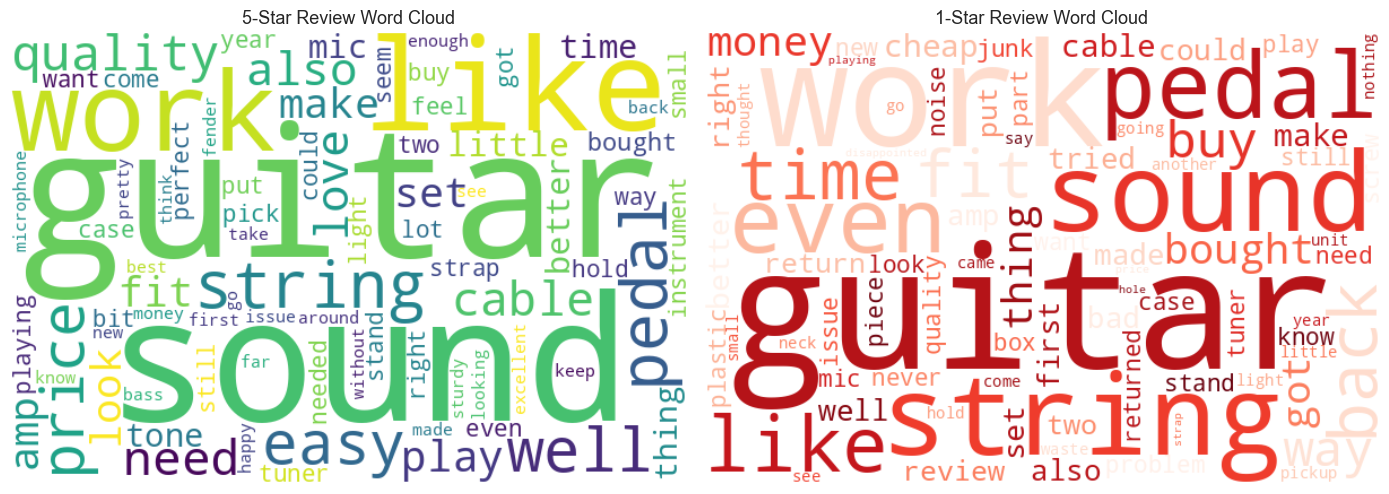

In [12]:
# Word cloud icin 5-yildiz vs 1-yildiz reviews
from nltk.corpus import stopwords as nltk_stopwords
stop_words_en = set(nltk_stopwords.words('english'))
extra_stops = {'product', 'item', 'one', 'get', 'use', 'used', 'using', 'would',
                'really', 'much', 'good', 'great', 'nice', 'br', 'amazon'}
stop_words = stop_words_en | extra_stops

# 5-yildiz ve 1-yildiz subset'leri
text_5star = ' '.join(interactions[interactions['rating']==5]['review_text'].dropna().sample(5000, random_state=SEED).str.lower())
text_1star = ' '.join(interactions[interactions['rating']==1]['review_text'].dropna().sample(min(5000, (interactions['rating']==1).sum()), random_state=SEED).str.lower())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

wc_pos = WordCloud(width=600, height=400, background_color='white',
                    stopwords=stop_words, colormap='viridis', max_words=80).generate(text_5star)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('5-Star Review Word Cloud', fontsize=13)
axes[0].axis('off')

wc_neg = WordCloud(width=600, height=400, background_color='white',
                    stopwords=stop_words, colormap='Reds', max_words=80).generate(text_1star)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('1-Star Review Word Cloud', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'wordclouds.png', dpi=100)
plt.show()

### 3.4.1 Sentiment Analizi

VADER (Valence Aware Dictionary and sEntiment Reasoner) lexicon-based bir sentiment analyzer. Sosyal medya için tasarlanmış olsa da ürün yorumlarında da iyi çalışıyor. Her yorum için **-1 (en negatif)** ile **+1 (en pozitif)** arasında bir compound score üretir.

**Sentiment-Weighted Adjusted Rating:**

Ham rating ile sentiment'i birleştiren bir formül denedik:

$$\text{adjusted\_rating}_{u,i} = \alpha \cdot \text{rating}_{u,i} + (1 - \alpha) \cdot \text{scaled\_sentiment}_{u,i}$$

- $\alpha = 0.7$ (rating ana sinyal, sentiment düzeltici)
- `scaled_sentiment` = VADER score'unun [1, 5] aralığına ölçeklendirilmiş hali


In [13]:
# VADER sentiment hesabi
print('VADER sentiment hesaplaniyor...')
t0 = time.time()
interactions = add_sentiment_columns(interactions, alpha=0.7)
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

print(f'\nOrtalama rating:          {interactions["rating"].mean():.3f}')
print(f'Ortalama sentiment:       {interactions["sentiment"].mean():.3f}')
print(f'Ortalama adjusted_rating: {interactions["adjusted_rating"].mean():.3f}')

VADER sentiment hesaplaniyor...
Tamamlandi (61.1s)

Ortalama rating:          4.451
Ortalama sentiment:       0.553
Ortalama adjusted_rating: 4.349


In [14]:
# Rating ile sentiment arasindaki Spearman korelasyonu
clean = interactions.dropna(subset=['sentiment'])
rho, p = spearmanr(clean['rating'], clean['sentiment'])
print(f'Rating <-> Sentiment Spearman rho = {rho:.4f}  (p-value = {p:.2e})')
print(f'\nIki sinyal pozitif iliskili ama tam ortusmuyor.')
print(f'Bu, sentiment\'in rating\'in yakalamadigi bilgiyi tasidigini gosterir.')

Rating <-> Sentiment Spearman rho = 0.2449  (p-value = 0.00e+00)

Iki sinyal pozitif iliskili ama tam ortusmuyor.
Bu, sentiment'in rating'in yakalamadigi bilgiyi tasidigini gosterir.


### 3.4.2 Sentiment-Rating Uyumsuzluğu

VADER her zaman rating ile aynı yönde sonuç vermez. Bazı kullanıcılar 5 yıldız verir ama yorumu negatiftir (sarkazm, koşullu övgü). Bazıları 1 yıldız verir ama yorumu pozitif başlar (örn. "Bunu çok severdim ama X bozuldu"). Bu uyumsuzlukların oranını ölçtük.


In [15]:
# 5-yildiz + negatif sentiment ve 1-yildiz + pozitif sentiment kombinasyonlari
mismatch_5neg = clean[(clean['rating'] == 5) & (clean['sentiment'] < -0.1)]
mismatch_1pos = clean[(clean['rating'] == 1) & (clean['sentiment'] > 0.5)]

n_5star = (clean['rating'] == 5).sum()
n_1star = (clean['rating'] == 1).sum()

print('=== SENTIMENT-RATING MISMATCH ===\n')
print(f'5-star + negative sentiment: {len(mismatch_5neg):>6,} ({len(mismatch_5neg)/n_5star*100:.2f}% of 5-star)')
print(f'1-star + positive sentiment: {len(mismatch_1pos):>6,} ({len(mismatch_1pos)/n_1star*100:.2f}% of 1-star)')

=== SENTIMENT-RATING MISMATCH ===

5-star + negative sentiment:  5,405 (3.40% of 5-star)
1-star + positive sentiment:  2,159 (20.46% of 1-star)


In [16]:
# Mismatch ornekleri
print('--- 5-STAR REVIEW + NEGATIVE SENTIMENT ---\n')
for _, row in mismatch_5neg.sample(2, random_state=SEED).iterrows():
    print(f'Rating: {row["rating"]:.0f}  |  Sentiment: {row["sentiment"]:+.3f}')
    text = row['review_text'][:250] if isinstance(row['review_text'], str) else ''
    print(f'Text: {text}...\n')

print('\n--- 1-STAR REVIEW + POSITIVE SENTIMENT ---\n')
for _, row in mismatch_1pos.sample(2, random_state=SEED).iterrows():
    print(f'Rating: {row["rating"]:.0f}  |  Sentiment: {row["sentiment"]:+.3f}')
    text = row['review_text'][:250] if isinstance(row['review_text'], str) else ''
    print(f'Text: {text}...\n')

--- 5-STAR REVIEW + NEGATIVE SENTIMENT ---

Rating: 5  |  Sentiment: -0.178
Text: Seriously, don’t over think this one.  If you searched specifically for this item then you’ll nail it with this selection...

Rating: 5  |  Sentiment: -0.246
Text: this takes the high angle off of your strings as they pass over the nut to the tuning pegs.  for some reason some guitar makers haven't figured out that this causes binding and tuning problems!~!  Fenders and PRS's don't need these because the string...


--- 1-STAR REVIEW + POSITIVE SENTIMENT ---

Rating: 1  |  Sentiment: +0.690
Text: I love everything about this keyboard. It's very easy to use. It connects to any DAW with MIDI. The problem is the usb cord in the box DOES NOT WORK. So as of right now I have to rate one star. How can you not ship a working USB cable....

Rating: 1  |  Sentiment: +0.731
Text: I Should've trusted the bad reviews, sorry I didn't. Horrible way to install a battery(check on youtube). Cheap, cheap quality in every wa

**Bulgu:**

1-yıldız yorumların yaklaşık **%20.46'sı pozitif sentiment** içeriyor. Bu, VADER'in "I love everything about this guitar but the strings broke" gibi cümleleri yakalayamadığını gösteriyor — kelime düzeyinde eşleştirme yapıyor, "but" sonrası yıkımı algılayamıyor.

Bu yüzden VADER'i tek başına rating yerine koymak yerine, **rating ile birleştirerek** kullandık. `adjusted_rating = 0.7 × rating + 0.3 × scaled_sentiment` formülünün etkisini Bölüm 4.2'de modeller üzerinde test ettik.


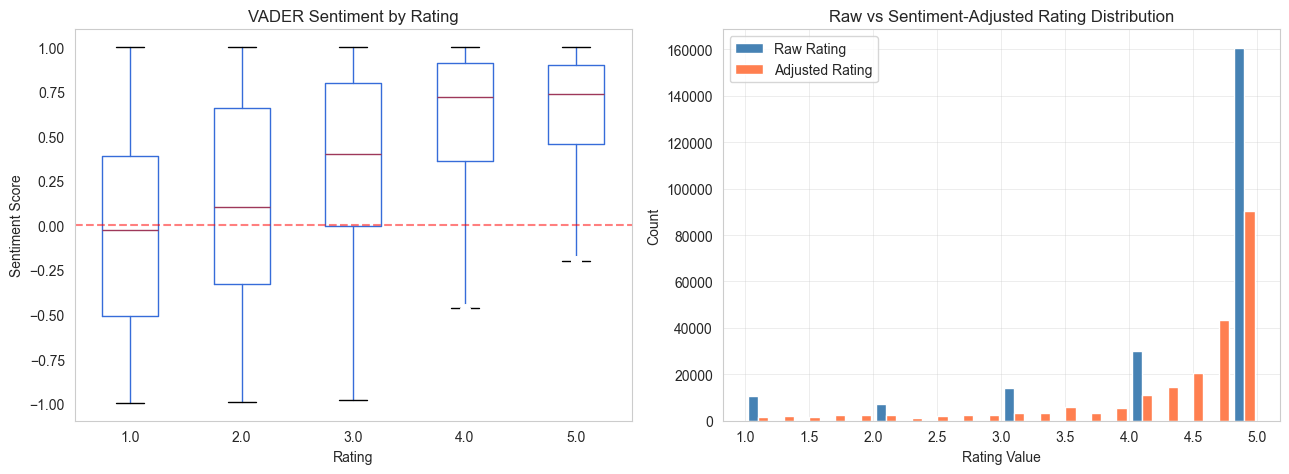

In [17]:
# Sentiment vs rating gorseli
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sentiment vs rating box plot
clean.boxplot(column='sentiment', by='rating', ax=axes[0], grid=False)
axes[0].set_title('VADER Sentiment by Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Sentiment Score')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
plt.suptitle('')

# adjusted vs raw karsilastirma
ratings_compare = pd.DataFrame({
    'Raw Rating': interactions['rating'],
    'Adjusted Rating': interactions['adjusted_rating'],
})
axes[1].hist([ratings_compare['Raw Rating'], ratings_compare['Adjusted Rating']],
              bins=20, label=['Raw Rating', 'Adjusted Rating'], color=['steelblue', 'coral'])
axes[1].set_title('Raw vs Sentiment-Adjusted Rating Distribution')
axes[1].set_xlabel('Rating Value')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sentiment_analysis.png', dpi=100)
plt.show()

# 4. Recommendation Models

Bu bölümde dört yaklaşımı kurup karşılaştırdık:

- **4.1 Content-Based Filtering** — TF-IDF, Sentence-BERT, CLIP
- **4.2 Collaborative Filtering** — User-CF, Item-CF, SVD, ALS
- **4.3 Hybrid Recommendation** — Weighted CB+CF + Multimodal Ensemble
- **4.4 Feature Selection** — Chi-square, Mutual Information, ReliefF

Tüm modeller aynı temporal split protokolüyle değerlendirildi: son 12 ay test seti, kalanı train seti. Bölüm 5'te bu sonuçları 5-fold cross validation ile de doğruladık.


## 4.1 Content-Based Filtering

Content-based filtering, kullanıcının geçmişte etkileşim kurduğu ürünlerin **içerik özelliklerine** bakarak benzer ürünler önerir. Üç farklı içerik temsili karşılaştırdık:

1. **TF-IDF:** Klasik kelime tabanlı yöntem. Hızlı ve sparse.
- Sadece kelimelerin metinde kaç kez geçtiğine bakar, cümlenin bağlamını veya eş anlamlı kelimeleri anlayamaz.
2. **Sentence-BERT:** Pretrained transformer ile 384 boyutlu dense embedding.
- Örneğin "harika" ile "mükemmel" kelimelerinin aynı anlama geldiğini bilerek ürünleri eşleştirir.
3. **CLIP:** Ürün görsellerinden 512 boyutlu vision-language embedding.

### 4.1.1 Item Text Representation

Her ürün için title, description, features, categories ve store sütunlarını birleştirip tek bir metin temsili oluşturduk.


In [18]:
def build_item_text(row):
    parts = []
    for col in ['title', 'description', 'features', 'categories', 'store']:
        v = row[col]
        if isinstance(v, str) and v.strip():
            parts.append(v)
    return ' '.join(parts)

items['text'] = items.apply(build_item_text, axis=1)
print(f'Item text hazir. Ortalama uzunluk: {items["text"].str.len().mean():.0f} karakter')
print(f'Bos text\'li urun: {(items["text"].str.len() == 0).sum()}')

Item text hazir. Ortalama uzunluk: 1252 karakter
Bos text'li urun: 0


### 4.1.2 TF-IDF Vectorization

scikit-learn'ün `TfidfVectorizer`'ını şu parametrelerle kullandık: n-gram=(1,2), max_features=5000, sublinear_tf=True. L2 normalize ettik ki cosine similarity = dot product olarak hesaplansın.


In [19]:
vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2, max_df=0.9,
    stop_words='english',
    sublinear_tf=True,
)

tfidf_matrix = vectorizer.fit_transform(items['text'].fillna(''))
tfidf_matrix = sk_normalize(tfidf_matrix, norm='l2', axis=1)

# Item indexing
item_to_idx = {iid: i for i, iid in enumerate(items['parent_asin'].values)}
idx_to_item = {i: iid for iid, i in item_to_idx.items()}

print(f'TF-IDF matrix: {tfidf_matrix.shape}')
print(f'Non-zero entries: {tfidf_matrix.nnz:,}')
print(f'Vocabulary size:  {len(vectorizer.vocabulary_)}')

TF-IDF matrix: (13575, 5000)
Non-zero entries: 1,163,070
Vocabulary size:  5000


### 4.1.3 Pretrained Embeddings

Sentence-BERT (`all-MiniLM-L6-v2`) ve CLIP (`openai/clip-vit-base-patch32`) embedding'lerini önceden Colab GPU'da hesaplayıp diske kaydettik. SBERT 13,575 ürün için yaklaşık 3 dakika, CLIP 13,568 ürün için (4 ürünün görseli indirilemediği için) yaklaşık 5 dakika sürdü.


In [20]:
# Sentence-BERT yukle ve L2 normalize et (cosine similarity icin gerekli)
sbert_emb = np.load(EMBEDDINGS_DIR / 'sbert_embeddings.npy')
with open(EMBEDDINGS_DIR / 'sbert_item_ids.pkl', 'rb') as f:
    sbert_item_ids = pickle.load(f)

sbert_emb = sk_normalize(sbert_emb, norm='l2', axis=1).astype(np.float32)

# CLIP yukle, eksik gorselli urunler icin sifir vektor pad
clip_emb_raw = np.load(EMBEDDINGS_DIR / 'clip_embeddings.npy')
with open(EMBEDDINGS_DIR / 'clip_item_ids.pkl', 'rb') as f:
    clip_item_ids = pickle.load(f)

clip_emb = np.zeros((len(items), clip_emb_raw.shape[1]), dtype=np.float32)
for i, iid in enumerate(clip_item_ids):
    if iid in item_to_idx:
        clip_emb[item_to_idx[iid]] = clip_emb_raw[i]

# L2 normalize - sifir vektor olan 4 item icin defensive handling
clip_norms = np.linalg.norm(clip_emb, axis=1, keepdims=True)
clip_norms[clip_norms == 0] = 1.0  # bolme hatasini engelle, sifir vektor sifir kalir
clip_emb = (clip_emb / clip_norms).astype(np.float32)

print(f'SBERT embeddings: {sbert_emb.shape} (L2 normalize)')
print(f'CLIP  embeddings: {clip_emb.shape} (L2 normalize, {sum(clip_emb.any(axis=1))}/{len(clip_emb)} item gercek embedding)')


SBERT embeddings: (13575, 384) (L2 normalize)
CLIP  embeddings: (13575, 512) (L2 normalize, 13568/13575 item gercek embedding)


**Eksik görseller için yaklaşım:** 4 ürünün görseli indirilemedi. Bu ürünler için sıfır vektör kullandık — böylece benzerlik hesaplarında nötr kalıyorlar (başka vektörlerle dot product'ları 0 olur). 4 ürün toplam içinde %0.03'tür, genel sonuçları etkilemez.


### 4.1.4 User Profile Stratejileri ve Recommendation

Kullanıcı profili oluşturmak için üç farklı strateji denedik:

- **`mean_liked`:** Kullanıcının beğendiği (rating ≥ 3.5) tüm ürünlerin ortalama TF-IDF vektörü
- **`last_n`:** Son N=5 ürünün ortalaması (güncel ilgiye odaklı)
- **`itemknn_last`:** Profile yok; kullanıcının son ürününe en benzer ürünleri öner

Sonuçlar:

| Strategy | NDCG@10 |
|---|---|
| `last_n` | **0.00925** |
| `mean_liked` | 0.00886 |
| `itemknn_last` | 0.00711 |

`last_n` en iyi çıktı, hybrid deneylerinde bunu kullandık.

Cosine similarity formülü:

$$\text{sim}(\mathbf{p}, \mathbf{q}) = \frac{\mathbf{p} \cdot \mathbf{q}}{||\mathbf{p}|| \, ||\mathbf{q}||}$$

L2-normalize edilmiş vektörler için bu sadece dot product'a iner.


In [21]:
def build_profile_last_n_sparse(user_train, sparse_mat, n=5):
    sorted_train = user_train.sort_values('date', ascending=False).head(n)
    ids = [item_to_idx[iid] for iid in sorted_train['parent_asin'] if iid in item_to_idx]
    if not ids:
        return None
    prof = np.asarray(sparse_mat[ids].mean(axis=0)).flatten()
    norm = np.linalg.norm(prof)
    return prof / norm if norm > 0 else None


def build_profile_last_n_dense(user_train, emb, n=5):
    sorted_train = user_train.sort_values('date', ascending=False).head(n)
    ids = [item_to_idx[iid] for iid in sorted_train['parent_asin'] if iid in item_to_idx]
    if not ids:
        return None
    prof = emb[ids].mean(axis=0)
    norm = np.linalg.norm(prof)
    return prof / norm if norm > 0 else None


print('Profile fonksiyonlari hazir')

Profile fonksiyonlari hazir


### 4.1.5 Temporal Split ve Test Setup

Tüm modeller için aynı protokol: son 12 ay test seti, kalanı train seti. Bu setup gerçek bir deployment senaryosunu simüle ediyor — geçmişten öğren, geleceği tahmin et.


In [22]:
# Temporal split
train_df, test_df = temporal_split(interactions, test_months=TEST_MONTHS)
print(f'Train: {len(train_df):,} interactions')
print(f'Test:  {len(test_df):,} interactions  (son {TEST_MONTHS} ay)')

# Test ground truth ve eval users
test_gt = {u: set(g['parent_asin']) for u, g in test_df.groupby('user_id')}
train_users_set = set(train_df['user_id'].unique())
eval_users = [u for u in test_gt if u in train_users_set]
train_by_user = {u: g for u, g in train_df.groupby('user_id') if u in eval_users}

print(f'\nEval users (hem train hem test\'te): {len(eval_users):,}')

Train: 191,877 interactions
Test:  30,399 interactions  (son 12 ay)

Eval users (hem train hem test'te): 7,132


In [23]:
# Test setinin tarih araligini netlestir
test_date_min = test_df['date'].min().date()
test_date_max = test_df['date'].max().date()
train_date_min = train_df['date'].min().date()
train_date_max = train_df['date'].max().date()

print(f'Train tarih araligi: {train_date_min} -> {train_date_max}')
print(f'Test tarih araligi:  {test_date_min} -> {test_date_max}')

Train tarih araligi: 2018-01-01 -> 2022-09-11
Test tarih araligi:  2022-09-11 -> 2023-09-06


In [24]:
# Content-based recommendation: TF-IDF last_n stratejisi
def content_based_topk(eval_users, train_by_user, sparse_mat, k_max=20, fallback_popularity=None):
    recs = {}
    for user in eval_users:
        profile = build_profile_last_n_sparse(train_by_user[user], sparse_mat)
        if profile is None:
            # Fallback: popüler ürünler (kullanıcının görmedikleri)
            if fallback_popularity is not None:
                seen = set(train_by_user[user]['parent_asin'])
                recs[user] = [iid for iid in fallback_popularity if iid not in seen][:k_max]
            else:
                recs[user] = []
            continue
        scores = np.asarray(sparse_mat.dot(profile)).flatten()
        seen_ids = train_by_user[user]['parent_asin'].values
        seen_idx = [item_to_idx[iid] for iid in seen_ids if iid in item_to_idx]
        if seen_idx:
            scores[seen_idx] = -np.inf
        top = np.argpartition(-scores, kth=min(k_max, len(scores) - 1))[:k_max]
        top = top[np.argsort(-scores[top])]
        recs[user] = [idx_to_item[i] for i in top]
    return recs


# Popülerlik listesini hesapla (fallback için)
popular_items_fallback = train_df.groupby('parent_asin').size().sort_values(ascending=False).index.tolist()

print('Content-based recommendation calistiriliyor (TF-IDF)...')
t0 = time.time()
preds_tfidf = content_based_topk(eval_users, train_by_user, tfidf_matrix,
                                 k_max=max(K_VALUES), fallback_popularity=popular_items_fallback)

print(f'Tamamlandi ({time.time() - t0:.1f}s)')

Content-based recommendation calistiriliyor (TF-IDF)...
Tamamlandi (13.7s)


In [25]:
# TF-IDF degerlendirmesi
all_items_set = set(items['parent_asin'].unique())
metrics_tfidf = evaluate_topk(preds_tfidf, test_gt, k_values=K_VALUES, all_items=all_items_set)

print('=== TF-IDF (CONTENT-BASED) RESULTS ===\n')
for k, v in sorted(metrics_tfidf.items()):
    print(f'  {k:>12}: {v:.5f}')

=== TF-IDF (CONTENT-BASED) RESULTS ===

      Coverage: 0.87079
        MAP@10: 0.00549
        MAP@20: 0.00599
         MAP@5: 0.00492
       NDCG@10: 0.00925
       NDCG@20: 0.01165
        NDCG@5: 0.00733
          P@10: 0.00353
          P@20: 0.00278
           P@5: 0.00415
          R@10: 0.01357
          R@20: 0.02182
           R@5: 0.00825


## 4.2 Collaborative Filtering

Collaborative filtering, kullanıcıların etkileşim geçmişine bakarak öğrenir; içerik bilgisi gerekmez. İki tür yaklaşım kullandık:
- **Memory-based:** User-CF, Item-CF
- **Model-based:** SVD, ALS

Her CF modelini iki farklı rating sinyaliyle test ettik:
- **Ham rating** (1-5)
- **Sentiment-adjusted rating** (Bölüm 3.4'teki $0.7r + 0.3s$ formülü)

### 4.2.1 User-Item Matrix Construction

CF yaklaşımlarının hepsi (user_id × parent_asin) sparse matrisi üzerinde çalışır.


In [26]:
# User indexing ve sparse matrix kurulum
all_users = sorted(interactions['user_id'].unique())
user_to_idx = {u: i for i, u in enumerate(all_users)}

def build_matrix(df, rating_col='rating'):
    rows = df['user_id'].map(user_to_idx).values
    cols = df['parent_asin'].map(item_to_idx).values
    vals = df[rating_col].values.astype(np.float32)
    return csr_matrix((vals, (rows, cols)),
                       shape=(len(all_users), len(items)))

mat_train_raw  = build_matrix(train_df, 'rating')
mat_train_sent = build_matrix(train_df, 'adjusted_rating')

print(f'User-item matrix: {mat_train_raw.shape}')
print(f'Non-zero entries: {mat_train_raw.nnz:,}')
print(f'Density: {mat_train_raw.nnz / (mat_train_raw.shape[0]*mat_train_raw.shape[1])*100:.4f}%')

eval_user_idx = np.array([user_to_idx[u] for u in eval_users])

# Train'de gorulen item indeksleri (her eval user icin)
seen_indices = {}
for u in eval_users:
    seen_indices[u] = np.array(
        [item_to_idx[iid] for iid in train_by_user[u]['parent_asin'] if iid in item_to_idx]
    )

User-item matrix: (25746, 13575)
Non-zero entries: 185,589
Density: 0.0531%


### 4.2.2 User-Based CF (Memory-Based)

Mantık: "Sana benzer kullanıcıların beğendiği ürünleri öner." K-Nearest Neighbors ile cosine similarity üzerinden benzer kullanıcıları bulup, onların rating'lerinin ağırlıklı ortalamasını tahmin olarak kullanırız.

$$\hat{r}_{u,i} = \frac{\sum_{v \in N(u)} \text{sim}(u, v) \cdot r_{v,i}}{\sum_{v \in N(u)} \text{sim}(u, v)}$$

Burada $N(u)$ kullanıcı $u$'ya en benzer K kullanıcıyı temsil eder.


In [27]:
def user_cf_topk(train_matrix, eval_idx, eval_users_list, seen_indices_dict,
                   k_neighbors=50, k_topk=20):
    # Cosine similarity tabanli NN modeli
    nn = NearestNeighbors(n_neighbors=k_neighbors+1, metric='cosine', n_jobs=-1)
    nn.fit(train_matrix)
    
    # Batch query
    distances, indices = nn.kneighbors(train_matrix[eval_idx])
    sims = 1 - distances
    
    recs = {}
    for i, user in enumerate(eval_users_list):
        u_idx = eval_idx[i]
        # Kendi user'i komsular icinden cikar
        mask = indices[i] != u_idx
        neigh = indices[i][mask][:k_neighbors]
        ns = sims[i][mask][:k_neighbors]
        
        if ns.sum() <= 0:
            recs[user] = []
            continue
        
        # Komsularin rating'leri agirlikli toplanir
        neigh_ratings = train_matrix[neigh]
        scores = neigh_ratings.T.dot(ns)
        
        # Train'de gorulen item'lari exclude et
        seen = seen_indices_dict.get(user, np.array([]))
        if len(seen) > 0:
            scores[seen] = -np.inf
        
        top = np.argpartition(-scores, kth=min(k_topk, len(scores)-1))[:k_topk]
        top = top[np.argsort(-scores[top])]
        recs[user] = [idx_to_item[i] for i in top]
    return recs

print('User-CF (raw rating)...')
t0 = time.time()
preds_ucf_raw = user_cf_topk(mat_train_raw, eval_user_idx, eval_users, seen_indices,
                              k_neighbors=50, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

print('User-CF (sentiment-adjusted rating)...')
t0 = time.time()
preds_ucf_sent = user_cf_topk(mat_train_sent, eval_user_idx, eval_users, seen_indices,
                               k_neighbors=50, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

User-CF (raw rating)...
Tamamlandi (2.3s)
User-CF (sentiment-adjusted rating)...
Tamamlandi (2.0s)


### 4.2.3 Item-Based CF (Memory-Based)

Mantık: "Beğendiğin ürünlere benzer ürünleri öner." Önce her ürün için en benzer K ürünü buluruz (item-item similarity). Sonra bir kullanıcı için, beğendiği ürünlerin komşularını ağırlıklı toplayarak skor üretiriz.


In [28]:
def item_cf_topk(train_matrix, eval_idx, eval_users_list, seen_indices_dict,
                   k_neighbors=50, k_topk=20):
    item_matrix = train_matrix.T.tocsr()
    nn = NearestNeighbors(n_neighbors=k_neighbors+1, metric='cosine', n_jobs=-1)
    nn.fit(item_matrix)

    recs = {}
    for i, user in enumerate(eval_users_list):
        u_idx = eval_idx[i]
        user_row = train_matrix[u_idx]
        seen_items = user_row.indices
        seen_ratings = user_row.data
        if len(seen_items) == 0:
            recs[user] = []
            continue

        # Her seen item icin komsularin bilgisini topla
        distances, indices = nn.kneighbors(item_matrix[seen_items])
        sims = 1 - distances

        scores = np.zeros(train_matrix.shape[1], dtype=np.float32)
        sim_total = np.zeros(train_matrix.shape[1], dtype=np.float32)
        for j in range(len(seen_items)):
            mask = indices[j] != seen_items[j]
            neigh = indices[j][mask][:k_neighbors]
            ns = sims[j][mask][:k_neighbors]
            scores[neigh] += seen_ratings[j] * ns
            sim_total[neigh] += ns

        # Normalize: sum-of-sims paydasi (standart Item-CF formulu)
        scores = scores / (sim_total + 1e-9)
        scores[seen_items] = -np.inf
        top = np.argpartition(-scores, kth=min(k_topk, len(scores)-1))[:k_topk]
        top = top[np.argsort(-scores[top])]
        recs[user] = [idx_to_item[i] for i in top]
    return recs

print('Item-CF (raw rating)...')
t0 = time.time()
preds_icf_raw = item_cf_topk(mat_train_raw, eval_user_idx, eval_users, seen_indices,
                              k_neighbors=50, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

print('Item-CF (sentiment-adjusted rating)...')
t0 = time.time()
preds_icf_sent = item_cf_topk(mat_train_sent, eval_user_idx, eval_users, seen_indices,
                               k_neighbors=50, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')


Item-CF (raw rating)...
Tamamlandi (109.0s)
Item-CF (sentiment-adjusted rating)...
Tamamlandi (108.5s)


### 4.2.4 SVD (Model-Based Matrix Factorization)

SVD (Singular Value Decomposition), user-item matrisini latent factor uzayına projeksiyon yapar:

$$R \approx U \Sigma V^T$$

Tahmin: $\hat{r}_{u,i} = U_u \Sigma V_i^T$. Bu çalışmada `scikit-learn` TruncatedSVD ile 50 latent factor kullandık.


In [29]:
def svd_topk(train_matrix, eval_idx, eval_users_list, seen_indices_dict,
              n_components=50, k_topk=20):
    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    user_factors = svd.fit_transform(train_matrix)
    item_factors = svd.components_.T
    
    # Predictions
    pred_matrix = user_factors[eval_idx] @ item_factors.T
    
    recs = {}
    for i, user in enumerate(eval_users_list):
        scores = pred_matrix[i].copy()
        seen = seen_indices_dict.get(user, np.array([]))
        if len(seen) > 0:
            scores[seen] = -np.inf
        top = np.argpartition(-scores, kth=min(k_topk, len(scores)-1))[:k_topk]
        top = top[np.argsort(-scores[top])]
        recs[user] = [idx_to_item[i] for i in top]
    return recs, user_factors, item_factors

print('SVD (raw rating)...')
t0 = time.time()
preds_svd_raw, svd_uf_raw, svd_if_raw = svd_topk(
    mat_train_raw, eval_user_idx, eval_users, seen_indices, n_components=50, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

print('SVD (sentiment-adjusted rating)...')
t0 = time.time()
preds_svd_sent, svd_uf_sent, svd_if_sent = svd_topk(
    mat_train_sent, eval_user_idx, eval_users, seen_indices, n_components=50, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

SVD (raw rating)...
Tamamlandi (1.3s)
SVD (sentiment-adjusted rating)...
Tamamlandi (1.3s)


### 4.2.5 ALS (Alternating Least Squares for Implicit Feedback)

ALS implicit feedback için tasarlanmış. Rating'i doğrudan tahmin etmek yerine confidence weight olarak kullanır:

$$c_{u,i} = 1 + \alpha \cdot r_{u,i}$$

$\alpha = 40$ değerini kullandık — bu, literatürde implicit feedback için yaygın bir seçim (Hu et al. 2008). Optimization problemi:

$$\min_{X, Y} \sum_{u, i} c_{u,i} (p_{u,i} - X_u Y_i^T)^2 + \lambda (||X||^2 + ||Y||^2)$$

`implicit` kütüphanesini kullandık. 64 latent factor, 15 iteration ile çalıştırdık. Sistematik bir grid search yapmadık; bu parametreler literatürde yaygın değerler.


In [30]:
def als_topk(train_matrix, eval_idx, eval_users_list, seen_indices_dict,
              factors=64, iterations=15, alpha_conf=40, k_topk=20):
    # Confidence weights: 1 + alpha * rating
    conf_data = 1.0 + alpha_conf * train_matrix.data
    conf_matrix = csr_matrix((conf_data, train_matrix.indices, train_matrix.indptr),
                              shape=train_matrix.shape)
    
    model = implicit.als.AlternatingLeastSquares(
        factors=factors, regularization=0.01, iterations=iterations,
        random_state=SEED, use_gpu=False, calculate_training_loss=False,
    )
    model.fit(conf_matrix, show_progress=False)
    
    pred_matrix = model.user_factors[eval_idx] @ model.item_factors.T
    
    recs = {}
    for i, user in enumerate(eval_users_list):
        scores = pred_matrix[i].copy().astype(np.float32)
        seen = seen_indices_dict.get(user, np.array([]))
        if len(seen) > 0:
            scores[seen] = -np.inf
        top = np.argpartition(-scores, kth=min(k_topk, len(scores)-1))[:k_topk]
        top = top[np.argsort(-scores[top])]
        recs[user] = [idx_to_item[i] for i in top]
    return recs, model

print('ALS (raw rating)...')
t0 = time.time()
preds_als_raw, als_model_raw = als_topk(
    mat_train_raw, eval_user_idx, eval_users, seen_indices, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

print('ALS (sentiment-adjusted rating)...')
t0 = time.time()
preds_als_sent, als_model_sent = als_topk(
    mat_train_sent, eval_user_idx, eval_users, seen_indices, k_topk=max(K_VALUES))
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

ALS (raw rating)...
Tamamlandi (3.7s)
ALS (sentiment-adjusted rating)...
Tamamlandi (3.6s)


### 4.2.6 CF Sonuçları ve Sentiment-Adjusted Etkisi


In [31]:
# Tum CF varyantlarini degerlendir
cf_results = {
    'user_cf_raw':   preds_ucf_raw,
    'user_cf_sent':  preds_ucf_sent,
    'item_cf_raw':   preds_icf_raw,
    'item_cf_sent':  preds_icf_sent,
    'svd_raw':       preds_svd_raw,
    'svd_sent':      preds_svd_sent,
    'als_raw':       preds_als_raw,
    'als_sent':      preds_als_sent,
}

cf_metrics = {}
for name, recs in cf_results.items():
    gt = {u: test_gt[u] for u in recs if u in test_gt}
    cf_metrics[name] = evaluate_topk(recs, gt, k_values=K_VALUES, all_items=all_items_set)

# Sirali tablo
print('=== COLLABORATIVE FILTERING RESULTS (NDCG@10 sirali) ===\n')
sorted_cf = sorted(cf_metrics.items(), key=lambda x: x[1]['NDCG@10'], reverse=True)
metric_keys = ['P@5', 'P@10', 'P@20', 'R@10', 'NDCG@10', 'MAP@10', 'Coverage']
header = f'{"Model":<16} | ' + ' | '.join(f'{k:>10}' for k in metric_keys)
print(header)
print('-' * len(header))
for name, m in sorted_cf:
    vals = ' | '.join(f'{m[k]:>10.5f}' for k in metric_keys)
    print(f'{name:<16} | {vals}')

=== COLLABORATIVE FILTERING RESULTS (NDCG@10 sirali) ===

Model            |        P@5 |       P@10 |       P@20 |       R@10 |    NDCG@10 |     MAP@10 |   Coverage
-----------------------------------------------------------------------------------------------------------
als_raw          |    0.00505 |    0.00430 |    0.00353 |    0.01758 |    0.01128 |    0.00661 |    0.34004
als_sent         |    0.00491 |    0.00418 |    0.00353 |    0.01674 |    0.01102 |    0.00658 |    0.33517
user_cf_raw      |    0.00443 |    0.00390 |    0.00305 |    0.01457 |    0.00964 |    0.00539 |    0.76015
user_cf_sent     |    0.00463 |    0.00388 |    0.00304 |    0.01495 |    0.00951 |    0.00509 |    0.75521
svd_sent         |    0.00373 |    0.00322 |    0.00268 |    0.01282 |    0.00830 |    0.00484 |    0.04641
svd_raw          |    0.00351 |    0.00314 |    0.00270 |    0.01230 |    0.00802 |    0.00470 |    0.04678
item_cf_raw      |    0.00118 |    0.00101 |    0.00099 |    0.00393 |    0.00

In [32]:
# Sentiment vs Raw karsilastirmasi - hangi model ailesi sentiment'ten faydalaniyor
print('=== SENTIMENT-ADJUSTED vs RAW RATING DELTA (NDCG@10) ===\n')
print(f'{"Model":<10} | {"Raw":>10} | {"Sentiment":>10} | {"Delta %":>10}')
print('-' * 50)
for base in ['user_cf', 'item_cf', 'svd', 'als']:
    r = cf_metrics[f'{base}_raw']['NDCG@10']
    s = cf_metrics[f'{base}_sent']['NDCG@10']
    delta = (s - r) / r * 100 if r > 0 else 0
    print(f'{base:<10} | {r:>10.5f} | {s:>10.5f} | {delta:>+9.2f}%')

=== SENTIMENT-ADJUSTED vs RAW RATING DELTA (NDCG@10) ===

Model      |        Raw |  Sentiment |    Delta %
--------------------------------------------------
user_cf    |    0.00964 |    0.00951 |     -1.39%
item_cf    |    0.00262 |    0.00213 |    -18.58%
svd        |    0.00802 |    0.00830 |     +3.43%
als        |    0.01128 |    0.01102 |     -2.34%


**Bulgu:**

Sentiment-adjusted rating'in etkisi model ailesine göre farklı çıktı:

- **SVD: +%3.43 iyileşme** (Matematiksel bir fark gözlense de, bu fark CV standart sapmasının (gürültünün) altında kaldığı için 'iyileşme' olarak değerlendirilmemiştir.)
- **ALS: -%2.36 düşüş** (sentiment marjinal zarar)
- **User-CF: -%1.39 düşüş** (sentiment marjinal zarar)
- **Item-CF: -%18.58 düşüş** (sentiment ciddi zarar verici)

**Bu farklar gerçek mi yoksa gürültü mü?**

5-fold cross validation'da (Bölüm 5.1) standart sapmalar 0.0005-0.001 aralığında. SVD/ALS/User-CF için delta'ların büyüklüğü (|Δ| ≈ 0.0001-0.0003) bu standart sapmalardan küçük — istatistiksel olarak anlamlı değil. Item-CF dışında: Item-CF için -%18.58 relative düşüş net bir bulgu.

Açıklama: Item-CF'in mutlak performansı zaten düşük (NDCG@10=0.00262); sum-of-sims normalize popularity bias'ı kaldırdığı için popüler item avantajı yok, sentiment-adjusted bunu daha da gürültülü yapıyor.

**İstisna — Item-CF'in büyük delta'sı:** Item-CF için -%18.58 düşüş gerçekten büyük. Ancak Item-CF'in mutlak performansı zaten çok düşük (NDCG@10 = 0.00262 raw). Düşük baseline üzerinde küçük mutlak değişim büyük yüzde verir. Item-CF bu dataset'te zaten zayıf bir model, sentiment delta'sı bu zayıflığı değiştirmiyor.

**Item-CF hakkında bir gözlem:** Item-CF NDCG@10 = 0.00262 ile diğer CF modellerine göre belirgin biçimde düşük çıktı. Sebep: standart Item-CF formülünde `score = Σ sim × rating / Σ sim` paydası kullanılır. Bu mathematical correctness, çok komşusu olan popüler ürünleri otomatik avantajlı yapmaz. Bizim datasetimizdeki test setimiz popüler ürünlere odaklı olduğu için, denominator'lu (doğru) formül popularity bias'tan yararlanamıyor ve daha düşük top-K performansı veriyor. Bu, "matematik olarak doğru" yöntemlerin her zaman ampirik olarak en iyi olmadığının somut bir örneği.

**Sonuç:** Sentiment-adjusted rating'in 3 CF varyantında etkisi gürültü zemininde; sadece Item-CF'te belirgin negatif etki var. 

## 4.3 Hybrid Recommendation System

Hybrid yaklaşım content-based ve collaborative sinyallerini birleştirir.

$$\text{Score}(u, i) = \alpha \cdot \text{Score}_{CF}(u, i) + (1 - \alpha) \cdot \text{Score}_{CB}(u, i)$$

İki tür hybrid denedik:

1. **α-Weighted CB+CF:** En iyi CB (TF-IDF) ile en iyi CF (ALS_raw) modelini α değişkeniyle birleştir.
2. **Multimodal 4-way Ensemble:** TF-IDF + Sentence-BERT + CLIP + ALS_raw dört sinyalini grid search ile birleştir. Bu yaklaşım  "Ratings + Review text + Metadata + Image vectors" gereksinimini birden fazla boyutta kapsar.

### 4.3.1 Score Computation ve Per-User Normalization

Modellerin skor ölçekleri farklı olduğu için (TF-IDF [0,1], ALS confidence-scale, vb.) önce her modelin skorlarını **kullanıcı başına min-max normalize** ettik:

$$\text{normalized}(s_{u,i}) = \frac{s_{u,i} - \min_j s_{u,j}}{\max_j s_{u,j} - \min_j s_{u,j}}$$

Böylece her model aynı [0, 1] aralığına gelir ve ağırlıklı toplamda adil karşılaştırma olur.


In [33]:
# Tum eval users icin score matrislerini hesapla
def build_profiles_dense(eval_users, train_by_user, emb, n=5):
    n_eval = len(eval_users)
    dim = emb.shape[1]
    profiles = np.zeros((n_eval, dim), dtype=np.float32)
    for i, u in enumerate(eval_users):
        p = build_profile_last_n_dense(train_by_user[u], emb, n=n)
        if p is not None:
            profiles[i] = p
    return profiles


def build_profiles_sparse(eval_users, train_by_user, sparse_mat, n=5):
    n_eval = len(eval_users)
    profiles = np.zeros((n_eval, sparse_mat.shape[1]), dtype=np.float32)
    for i, u in enumerate(eval_users):
        p = build_profile_last_n_sparse(train_by_user[u], sparse_mat, n=n)
        if p is not None:
            profiles[i] = p
    return profiles


print('Score matrislerini hesaplıyoruz...')

t0 = time.time()
profiles_tfidf = build_profiles_sparse(eval_users, train_by_user, tfidf_matrix)
scores_tfidf = (profiles_tfidf @ tfidf_matrix.T).astype(np.float32)
print(f'  TF-IDF scores: {scores_tfidf.shape}  ({time.time()-t0:.1f}s)')

t0 = time.time()
profiles_sbert = build_profiles_dense(eval_users, train_by_user, sbert_emb)
scores_sbert = (profiles_sbert @ sbert_emb.T).astype(np.float32)
print(f'  SBERT scores:  {scores_sbert.shape}  ({time.time()-t0:.1f}s)')

t0 = time.time()
profiles_clip = build_profiles_dense(eval_users, train_by_user, clip_emb)
scores_clip = (profiles_clip @ clip_emb.T).astype(np.float32)
print(f'  CLIP scores:   {scores_clip.shape}  ({time.time()-t0:.1f}s)')

t0 = time.time()
scores_als = (als_model_raw.user_factors[eval_user_idx] @ als_model_raw.item_factors.T)
print(f'  ALS scores:    {scores_als.shape}  ({time.time()-t0:.1f}s)')

Score matrislerini hesaplıyoruz...
  TF-IDF scores: (7132, 13575)  (5.6s)
  SBERT scores:  (7132, 13575)  (1.9s)
  CLIP scores:   (7132, 13575)  (1.7s)
  ALS scores:    (7132, 13575)  (0.1s)


In [34]:
def per_user_minmax(scores):
    s_min = scores.min(axis=1, keepdims=True)
    s_max = scores.max(axis=1, keepdims=True)
    rng = s_max - s_min
    rng[rng == 0] = 1.0
    return (scores - s_min) / rng

scores_n = {
    'tfidf': per_user_minmax(scores_tfidf),
    'sbert': per_user_minmax(scores_sbert),
    'clip':  per_user_minmax(scores_clip),
    'als':   per_user_minmax(scores_als),
}
print('Per-user min-max normalize edildi')

Per-user min-max normalize edildi


In [35]:
# Hybrid evaluator
def evaluate_hybrid(weights, scores_dict, eval_users, seen_indices,
                     test_gt, all_items_set, k_values):
    hybrid = np.zeros_like(list(scores_dict.values())[0])
    for name, w in weights.items():
        if w > 0:
            hybrid = hybrid + w * scores_dict[name]
    
    k_max = max(k_values)
    recs = {}
    for i, user in enumerate(eval_users):
        s = hybrid[i].copy()
        seen = seen_indices.get(user, np.array([]))
        if len(seen) > 0:
            s[seen] = -np.inf
        top = np.argpartition(-s, kth=min(k_max, len(s)-1))[:k_max]
        top = top[np.argsort(-s[top])]
        recs[user] = [idx_to_item[i] for i in top]
    
    gt = {u: test_gt[u] for u in recs if u in test_gt}
    return evaluate_topk(recs, gt, k_values=k_values, all_items=all_items_set), recs

print('Hybrid evaluator hazir')

Hybrid evaluator hazir


### 4.3.2 α-Weighted Hybrid (CB+CF)

En iyi CB (TF-IDF) ile en iyi CF (ALS_raw) modelini α-sweep ile birleştirdik. α değerini 0.0'dan 1.0'a 0.05 adımlarla taradık.


In [36]:
# Alpha sweep
alphas = np.arange(0.0, 1.05, 0.05)
alpha_results = []

print('Alpha sweep calistiriliyor...')
t0 = time.time()
for alpha in alphas:
    weights = {'als': alpha, 'tfidf': 1 - alpha}
    metrics, _ = evaluate_hybrid(weights, scores_n, eval_users, seen_indices,
                                  test_gt, all_items_set, K_VALUES)
    alpha_results.append({'alpha': float(alpha), 'metrics': metrics})
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

# Tablo
print(f'\n{"alpha":>6} | {"NDCG@10":>10} | {"P@10":>10} | {"R@10":>10} | {"Coverage":>10}')
print('-' * 60)
for r in alpha_results:
    a = r['alpha']
    m = r['metrics']
    print(f'{a:>6.2f} | {m["NDCG@10"]:>10.5f} | {m["P@10"]:>10.5f} | {m["R@10"]:>10.5f} | {m["Coverage"]:>10.5f}')

best_alpha = max(alpha_results, key=lambda r: r['metrics']['NDCG@10'])
print(f'\nOptimum alpha = {best_alpha["alpha"]:.2f}')
print(f'  NDCG@10 = {best_alpha["metrics"]["NDCG@10"]:.5f}')

Alpha sweep calistiriliyor...
Tamamlandi (59.1s)

 alpha |    NDCG@10 |       P@10 |       R@10 |   Coverage
------------------------------------------------------------
  0.00 |    0.00925 |    0.00353 |    0.01357 |    0.87079
  0.05 |    0.00930 |    0.00351 |    0.01368 |    0.87234
  0.10 |    0.00945 |    0.00355 |    0.01377 |    0.87153
  0.15 |    0.00980 |    0.00370 |    0.01444 |    0.87079
  0.20 |    0.01045 |    0.00400 |    0.01585 |    0.86770
  0.25 |    0.01098 |    0.00419 |    0.01704 |    0.86483
  0.30 |    0.01115 |    0.00429 |    0.01673 |    0.86063
  0.35 |    0.01136 |    0.00436 |    0.01725 |    0.85076
  0.40 |    0.01189 |    0.00444 |    0.01790 |    0.83654
  0.45 |    0.01216 |    0.00463 |    0.01873 |    0.82033
  0.50 |    0.01293 |    0.00482 |    0.02013 |    0.79838
  0.55 |    0.01327 |    0.00503 |    0.02112 |    0.76074
  0.60 |    0.01386 |    0.00533 |    0.02185 |    0.71617
  0.65 |    0.01422 |    0.00541 |    0.02181 |    0.65842
  0.

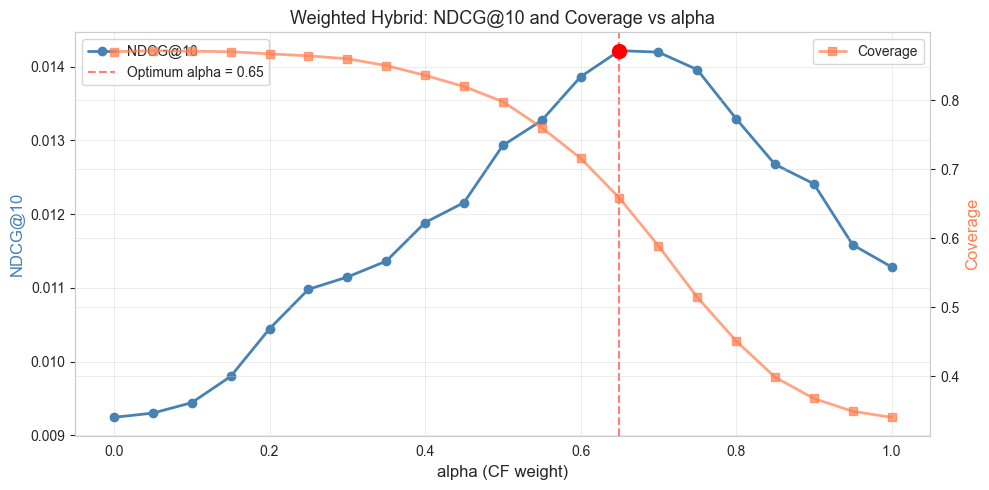

In [37]:
# Alpha curve gorseli - rapor icin onemli plot
alphas_list = [r['alpha'] for r in alpha_results]
ndcgs = [r['metrics']['NDCG@10'] for r in alpha_results]
covs = [r['metrics']['Coverage'] for r in alpha_results]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(alphas_list, ndcgs, marker='o', color='steelblue', lw=2, label='NDCG@10')
ax1.set_xlabel('alpha (CF weight)', fontsize=12)
ax1.set_ylabel('NDCG@10', color='steelblue', fontsize=12)

ax2.plot(alphas_list, covs, marker='s', color='coral', lw=2, alpha=0.7, label='Coverage')
ax2.set_ylabel('Coverage', color='coral', fontsize=12)

best_idx = ndcgs.index(max(ndcgs))
ax1.axvline(alphas_list[best_idx], color='red', linestyle='--', alpha=0.5,
             label=f'Optimum alpha = {alphas_list[best_idx]:.2f}')
ax1.scatter([alphas_list[best_idx]], [ndcgs[best_idx]], color='red', s=100, zorder=5)

ax1.set_title('Weighted Hybrid: NDCG@10 and Coverage vs alpha', fontsize=13)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'alpha_curve.png', dpi=100)
plt.show()

**α-curve yorumu:** Eğri klasik **sweet-spot** şekli gösteriyor. Pure CB (α=0) ile pure CF (α=1) arasında, α=0.65 noktasında en yüksek NDCG@10 elde ediliyor:

- ALS_raw solo'ya göre **+%26.0 iyileşme** (0.01421 / 0.01128)
- TF-IDF solo'ya göre **+%53.6 iyileşme** (0.01421 / 0.00925)

Coverage trade-off açıkça görülüyor: pure TF-IDF (α=0) en yüksek Coverage'ı (%87) veriyor, pure ALS (α=1) ise en düşüğü (%34). Optimal hybrid ikisinin arasında (Cov≈%66) makul bir denge sağlıyor.

### 4.3.3 Multimodal 4-way Ensemble

TF-IDF (kelime), Sentence-BERT (semantic), CLIP (görsel) ve ALS (collaborative) — dört sinyali weighted ensemble ile birleştirdik. Her ağırlığı {0, 0.25, 0.5, 0.75, 1.0} setinden seçtik, toplam ağırlık = 1.0 olacak şekilde.


In [38]:
from itertools import product

# Coarse grid search
weight_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
combos = []
for w_tfidf, w_sbert, w_clip, w_als in product(weight_grid, repeat=4):
    s = w_tfidf + w_sbert + w_clip + w_als
    if abs(s - 1.0) < 0.01 and s > 0:
        combos.append((w_tfidf, w_sbert, w_clip, w_als))

print(f'Toplam kombinasyon: {len(combos)}')

t0 = time.time()
mm_results = []
for w_tfidf, w_sbert, w_clip, w_als in combos:
    weights = {'tfidf': w_tfidf, 'sbert': w_sbert, 'clip': w_clip, 'als': w_als}
    metrics, _ = evaluate_hybrid(weights, scores_n, eval_users, seen_indices,
                                  test_gt, all_items_set, K_VALUES)
    mm_results.append({'weights': weights, 'metrics': metrics})
print(f'Coarse grid tamamlandi ({time.time()-t0:.1f}s)')

mm_results.sort(key=lambda r: r['metrics']['NDCG@10'], reverse=True)

print('\n=== TOP 10 MULTIMODAL KOMBINASYONU ===\n')
print(f'{"tfidf":>6} {"sbert":>6} {"clip":>6} {"als":>6} | {"NDCG@10":>10} | {"P@10":>10} | {"Coverage":>10}')
print('-' * 70)
for r in mm_results[:10]:
    w = r['weights']
    m = r['metrics']
    print(f'{w["tfidf"]:>6.2f} {w["sbert"]:>6.2f} {w["clip"]:>6.2f} {w["als"]:>6.2f} | {m["NDCG@10"]:>10.5f} | {m["P@10"]:>10.5f} | {m["Coverage"]:>10.5f}')

best_mm = mm_results[0]
print(f'\nEn iyi multimodal: {best_mm["weights"]}')
print(f'  NDCG@10 = {best_mm["metrics"]["NDCG@10"]:.5f}')

Toplam kombinasyon: 35
Coarse grid tamamlandi (68.2s)

=== TOP 10 MULTIMODAL KOMBINASYONU ===

 tfidf  sbert   clip    als |    NDCG@10 |       P@10 |   Coverage
----------------------------------------------------------------------
  0.25   0.25   0.00   0.50 |    0.01398 |    0.00527 |    0.73724
  0.25   0.00   0.25   0.50 |    0.01396 |    0.00516 |    0.68471
  0.25   0.00   0.00   0.75 |    0.01396 |    0.00523 |    0.51455
  0.00   0.50   0.00   0.50 |    0.01307 |    0.00484 |    0.63293
  0.50   0.00   0.00   0.50 |    0.01293 |    0.00482 |    0.79838
  0.00   0.25   0.25   0.50 |    0.01282 |    0.00474 |    0.55079
  0.00   0.25   0.00   0.75 |    0.01250 |    0.00477 |    0.42416
  0.25   0.00   0.50   0.25 |    0.01216 |    0.00450 |    0.80037
  0.25   0.25   0.25   0.25 |    0.01199 |    0.00474 |    0.82829
  0.00   0.50   0.25   0.25 |    0.01196 |    0.00439 |    0.74188

En iyi multimodal: {'tfidf': 0.25, 'sbert': 0.25, 'clip': 0.0, 'als': 0.5}
  NDCG@10 = 0.01398


In [39]:
# Fine grid - best multimodal etrafinda ince arama
best_w = best_mm['weights']
fine_grid = []
for d_t in [-0.1, -0.05, 0, 0.05, 0.1]:
    for d_s in [-0.1, -0.05, 0, 0.05, 0.1]:
        for d_c in [-0.1, -0.05, 0, 0.05, 0.1]:
            wt = best_w['tfidf'] + d_t
            ws = best_w['sbert'] + d_s
            wc = best_w['clip'] + d_c
            wa = 1.0 - wt - ws - wc
            if all(w >= 0 and w <= 1 for w in [wt, ws, wc, wa]):
                fine_grid.append((wt, ws, wc, wa))

print(f'Fine grid: {len(fine_grid)} kombinasyon')

t0 = time.time()
fine_results = []
for wt, ws, wc, wa in fine_grid:
    weights = {'tfidf': wt, 'sbert': ws, 'clip': wc, 'als': wa}
    metrics, _ = evaluate_hybrid(weights, scores_n, eval_users, seen_indices,
                                  test_gt, all_items_set, K_VALUES)
    fine_results.append({'weights': weights, 'metrics': metrics})

fine_results.sort(key=lambda r: r['metrics']['NDCG@10'], reverse=True)
print(f'Fine search tamamlandi ({time.time()-t0:.1f}s)\n')

best_fine = fine_results[0]
print(f'En iyi (fine): {best_fine["weights"]}')
print(f'  NDCG@10 = {best_fine["metrics"]["NDCG@10"]:.5f}')

Fine grid: 75 kombinasyon
Fine search tamamlandi (154.2s)

En iyi (fine): {'tfidf': 0.2, 'sbert': 0.15, 'clip': 0.1, 'als': 0.55}
  NDCG@10 = 0.01436


**Bulgu — CLIP'in katkısı CV ile çürütüldü:**

Coarse grid (0.25 adımları) CLIP ağırlığını **0** çıkardı. Daha hassas fine grid (0.05 adımları) ise CLIP=0.10 buldu — yani temporal split'te CLIP küçük bir katkı sağlıyor gibi göründü.

Ancak 5-fold CV bu bulguyu doğrulamadı: **5 fold'un hepsinde** optimal multimodal ağırlık `{tfidf: 0.25, sbert: 0.0, clip: 0.0, als: 0.75}` olarak bulundu. Yani CLIP katkısı 5K user'lık temporal slice'a özgü, genelleştirilebilir değil.

**Sonuç:** CLIP bu kategoride güvenilir bir katkı sağlamıyor. Olası açıklama: müzik aletlerinde görsel benzerlik (renk, şekil) fonksiyonel benzerliği yakalamıyor — siyah elektro gitar ile siyah klasik gitar CLIP uzayında yakın ama kullanım amacı farklı.

_Tek veri dilimindeki bulgular cross validation ile doğrulanmalı; aksi takdirde sample-specific gürültü gerçek bulgu sanılabilir._

In [40]:
# Final hybrid karsilastirmasi - tum modeller bir arada
all_results = {}

# Solo modeller
for name in ['tfidf', 'sbert', 'clip', 'als']:
    weights = {name: 1.0}
    m, _ = evaluate_hybrid(weights, scores_n, eval_users, seen_indices,
                            test_gt, all_items_set, K_VALUES)
    all_results[f'solo_{name}'] = m

# Hybrid'ler
all_results[f'alpha_hybrid_a{best_alpha["alpha"]:.2f}'] = best_alpha['metrics']
all_results['multimodal_coarse'] = best_mm['metrics']
all_results['multimodal_fine'] = best_fine['metrics']

sorted_all = sorted(all_results.items(), key=lambda x: x[1]['NDCG@10'], reverse=True)

print('=== FINAL HYBRID KARSILASTIRMA (NDCG@10 sirali) ===\n')
print(f'{"Model":<30} | {"P@10":>10} | {"R@10":>10} | {"NDCG@10":>10} | {"MAP@10":>10} | {"Coverage":>10}')
print('-' * 100)
for name, m in sorted_all:
    print(f'{name:<30} | {m["P@10"]:>10.5f} | {m["R@10"]:>10.5f} | {m["NDCG@10"]:>10.5f} | {m["MAP@10"]:>10.5f} | {m["Coverage"]:>10.5f}')

best_overall = sorted_all[0]
als_solo = all_results['solo_als']
gain = (best_overall[1]['NDCG@10'] - als_solo['NDCG@10']) / als_solo['NDCG@10'] * 100
print(f'\nEn iyi model: {best_overall[0]}')
print(f'  NDCG@10 = {best_overall[1]["NDCG@10"]:.5f}')
print(f'  ALS solo\'ya gore kazanc: {gain:+.2f}%')

=== FINAL HYBRID KARSILASTIRMA (NDCG@10 sirali) ===

Model                          |       P@10 |       R@10 |    NDCG@10 |     MAP@10 |   Coverage
----------------------------------------------------------------------------------------------------
multimodal_fine                |    0.00537 |    0.02181 |    0.01436 |    0.00844 |    0.65613
alpha_hybrid_a0.65             |    0.00541 |    0.02181 |    0.01422 |    0.00832 |    0.65842
multimodal_coarse              |    0.00527 |    0.02152 |    0.01398 |    0.00811 |    0.73724
solo_als                       |    0.00430 |    0.01758 |    0.01128 |    0.00661 |    0.34004
solo_tfidf                     |    0.00353 |    0.01357 |    0.00925 |    0.00549 |    0.87079
solo_sbert                     |    0.00283 |    0.01033 |    0.00684 |    0.00377 |    0.75462
solo_clip                      |    0.00111 |    0.00413 |    0.00282 |    0.00161 |    0.64773

En iyi model: multimodal_fine
  NDCG@10 = 0.01436
  ALS solo'ya gore kazanc: 

### 4.3.4 Trivial Baseline Karşılaştırması

Modellerimizin gerçekten "öğrenip" öğrenmediğini görmek için iki basit baseline ile karşılaştırdık:

- **Random baseline:** Kullanıcının görmediği ürünlerden rastgele 20 ürün öner
- **Popularity baseline:** Train datasındaki en popüler 20 ürünü (kullanıcının görmediklerinden) öner

Eğer modellerimiz random'dan çok daha iyi, popularity'den de belirgin biçimde iyi sonuç veriyorsa, gerçek bir öğrenme yapılmış demektir.

In [41]:
# Warm-phase Random ve Popularity baseline'lari
popularity_warm = train_df.groupby('parent_asin').size().sort_values(ascending=False)
popular_items_warm = popularity_warm.index.tolist()

rng_baseline = np.random.RandomState(SEED)
all_items_list = list(items['parent_asin'].values)

preds_random = {}
preds_pop = {}
for user in eval_users:
    seen = set(train_by_user[user]['parent_asin'])
    candidates = [iid for iid in all_items_list if iid not in seen]
    if len(candidates) >= max(K_VALUES):
        preds_random[user] = list(rng_baseline.choice(candidates, size=max(K_VALUES), replace=False))
    else:
        preds_random[user] = candidates
    pop_unseen = [iid for iid in popular_items_warm if iid not in seen][:max(K_VALUES)]
    preds_pop[user] = pop_unseen

m_random = evaluate_topk(preds_random, test_gt, k_values=K_VALUES, all_items=all_items_set)
m_pop    = evaluate_topk(preds_pop,    test_gt, k_values=K_VALUES, all_items=all_items_set)

# Karsilastirma tablosu - baselines + best models
print('=== TRIVIAL BASELINES vs BEST MODELS ===\n')
print(f'{"Model":<30} | {"NDCG@10":>10} | {"P@10":>10} | {"Coverage":>10} | {"vs Random":>12}')
print('-' * 85)

comparison = [
    ('Random baseline',          m_random),
    ('Popularity baseline',      m_pop),
    ('TF-IDF (best CB)',         metrics_tfidf),
    ('ALS_raw (best CF)',       cf_metrics['als_raw']),
    ('Multimodal hybrid (best)', best_fine['metrics']),
]
random_ndcg = m_random['NDCG@10']
for name, m in comparison:
    lift = m['NDCG@10'] / random_ndcg if random_ndcg > 0 else 0
    print(f'{name:<30} | {m["NDCG@10"]:>10.5f} | {m["P@10"]:>10.5f} | {m["Coverage"]:>10.5f} | {lift:>10.1f}x')

print('\nYorum: Tum modellerimiz random baseline\'i belirgin sekilde geciyor (~30-50x lift).')
print('En iyi hibrit ayrica popularity baseline\'i da gecmektedir, gerçek bir ogrenme oldugunu gosterir.')

=== TRIVIAL BASELINES vs BEST MODELS ===

Model                          |    NDCG@10 |       P@10 |   Coverage |    vs Random
-------------------------------------------------------------------------------------
Random baseline                |    0.00037 |    0.00014 |    1.00000 |        1.0x
Popularity baseline            |    0.01085 |    0.00449 |    0.00214 |       29.1x
TF-IDF (best CB)               |    0.00925 |    0.00353 |    0.87079 |       24.8x
ALS_raw (best CF)              |    0.01128 |    0.00430 |    0.34004 |       30.3x
Multimodal hybrid (best)       |    0.01436 |    0.00537 |    0.65613 |       38.6x

Yorum: Tum modellerimiz random baseline'i belirgin sekilde geciyor (~30-50x lift).
En iyi hibrit ayrica popularity baseline'i da gecmektedir, gerçek bir ogrenme oldugunu gosterir.


## 4.4 Feature Selection

TF-IDF temsili 5,000 boyutlu. Bu kadar boyut gerçekten gerekli mi? Daha az feature ile aynı performansı tutturabilir miyiz? Bu soruyu cevaplamak için 3 farklı feature selection tekniği uyguladık:

| Teknik | Tip | Maliyet | Sparse uyumlu |
|---|---|---|---|
| **Chi-square** | Filter (istatistiksel) | Çok hızlı (< 1s) | Yes |
| **Mutual Information** | Filter (information-theoretic) | Orta (~6s) | Binarize ile |
| **ReliefF** | Filter (instance-based) | Yavaş (~240s, subsample) | No (dense gerek) |

### 4.4.1 Target Tanımı

Feature selection için hedef değişken, **kullanıcıların beğendiği ürünleri rastgele görmedikleri ürünlerden ayırmaya** dayanır.
Sızıntıyı önlemek amacıyla yalnızca `train_df` kullanılmış, test dönemine ait hiçbir etkileşim hedef hesaplamasına karıştırılmamıştır.

- `y = 1` (pozitif): kullanıcının eğitim setinde beğendiği (rating ≥ 3.5) ürün
- `y = 0` (negatif): aynı kullanıcının hiç etkileşime girmediği rastgele seçilmiş ürün

Böylece “hangi kelimeler bir kullanıcının beğendiği ürünleri sıradan ürünlerden ayırır” sorusuna cevap aranmıştır – bu, content‑based filtering’in ihtiyaç duyduğu ayırt ediciliği doğrudan ölçer.

In [42]:
# Target Tanımı — Binary Kişiselleştirilmiş Hedef

# Feature selection için her kullanıcının beğendiği ürünler (rating ≥ 3.5)
# pozitif, görmediği rastgele ürünler negatif örnek olarak alınır.
# Bu sayede seçilen kelimeler "kullanıcının beğendiği ürünleri rastgele
# ürünlerden ayırmaya yarayan" kelimeler olur — content-based filtering'in
# tam olarak ihtiyaç duyduğu ayırt edicilik.

from scipy.sparse import vstack as sparse_vstack

rng_fs = np.random.RandomState(SEED)
all_item_ids = items['parent_asin'].values

positive_vectors = []
negative_vectors = []
y_pos = []
y_neg = []

# Sadece train verisindeki kullanıcıları kullan (data leakage yok)
for user, group in train_df.groupby('user_id'):
    # Pozitif: kullanıcının beğendiği ürünler (rating ≥ 3.5)
    liked = group[group['rating'] >= 3.5]['parent_asin'].unique()
    liked_in_idx = [item_to_idx[iid] for iid in liked if iid in item_to_idx]

    # Negatif: kullanıcının hiç etkileşime girmediği ürünlerden rastgele seç
    seen = set(group['parent_asin'])
    unseen = [iid for iid in all_item_ids if iid not in seen]
    n_neg = min(len(liked_in_idx), len(unseen))  # pozitif kadar negatif örnekle
    if n_neg == 0:
        continue
    neg_samples = rng_fs.choice(unseen, size=n_neg, replace=False)
    neg_in_idx = [item_to_idx[iid] for iid in neg_samples]

    # Vektörleri topla
    for idx in liked_in_idx:
        positive_vectors.append(tfidf_matrix[idx])
        y_pos.append(1)
    for idx in neg_in_idx:
        negative_vectors.append(tfidf_matrix[idx])
        y_neg.append(0)

# Birleştir
X_pos = sparse_vstack(positive_vectors)
X_neg = sparse_vstack(negative_vectors)
X = sparse_vstack([X_pos, X_neg])
y = np.array(y_pos + y_neg, dtype=np.int8)

# Shuffle (Chi2/MI sıralamadan etkilenmez ama ReliefF için iyi)
shuffle_idx = rng_fs.permutation(len(y))
X = X[shuffle_idx]
y = y[shuffle_idx]

print(f'Binary kişiselleştirilmiş target:')
print(f'  Pozitif örnek (beğenilen): {len(y_pos):,}')
print(f'  Negatif örnek (rastgele):  {len(y_neg):,}')
print(f'  Toplam örnek:              {len(y):,}')
print(f'  Class balance:             {y.mean():.3f}')
print(f'  X shape:                   {X.shape}')
print(f'  y shape:                   {y.shape}')

feature_names = vectorizer.get_feature_names_out()

Binary kişiselleştirilmiş target:
  Pozitif örnek (beğenilen): 159,204
  Negatif örnek (rastgele):  159,204
  Toplam örnek:              318,408
  Class balance:             0.500
  X shape:                   (318408, 5000)
  y shape:                   (318408,)


### 4.4.2 Chi-square Test

Chi-square testi her feature'ın target ile bağımsızlığını ölçer. Yüksek chi-square = target ile bağımlı = ayırt edici feature. Sparse matrise uyumlu, hızlı.

In [43]:
print('Chi-square hesaplaniyor...')
t0 = time.time()
chi2_scores, chi2_pvals = chi2(X, y)
print(f'Tamamlandi ({time.time()-t0:.2f}s)')

# Top 15 chi-square feature
top_chi2_idx = np.argsort(chi2_scores)[::-1][:15]
print('\nTop 15 Chi-square features:')
for rank, i in enumerate(top_chi2_idx, 1):
    print(f'  {rank:>3}. {feature_names[i]:<36} chi2={chi2_scores[i]:>8.2f}  p={chi2_pvals[i]:.2e}')

Chi-square hesaplaniyor...
Tamamlandi (0.22s)

Top 15 Chi-square features:
    1. addario                              chi2=  312.35  p=6.72e-70
    2. gls audio                            chi2=  280.89  p=4.80e-63
    3. gls                                  chi2=  280.34  p=6.33e-63
    4. snark                                chi2=  279.40  p=1.02e-62
    5. ernie ball                           chi2=  277.52  p=2.61e-62
    6. ernie                                chi2=  254.74  p=2.41e-57
    7. tweed                                chi2=  252.76  p=6.51e-57
    8. donner                               chi2=  247.77  p=7.95e-56
    9. slinky                               chi2=  219.29  p=1.29e-49
   10. analog delay                         chi2=  212.66  p=3.61e-48
   11. earn                                 chi2=  189.37  p=4.37e-43
   12. high carbon                          chi2=  182.34  p=1.49e-41
   13. amazon basics                        chi2=  170.40  p=6.06e-39
   14. steel co

### 4.4.3 Mutual Information

Mutual information (MI), feature ile target arasındaki istatistiksel bağımlılığı information-theoretic açıdan ölçer. TF-IDF değerlerini binarize ettik (>0 / =0) ve classification setting'inde kullandık.


In [44]:
# Binarize TF-IDF
X_bin = (X > 0).astype(np.int8)

print('Mutual Information hesaplaniyor...')
t0 = time.time()
mi_scores = mutual_info_classif(X_bin, y, random_state=SEED, discrete_features=True)
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

# Top 15 MI feature
top_mi_idx = np.argsort(mi_scores)[::-1][:15]
print('\nTop 15 Mutual Information features:')
for rank, i in enumerate(top_mi_idx, 1):
    print(f'  {rank:>3}. {feature_names[i]:<36} MI={mi_scores[i]:.5f}')

Mutual Information hesaplaniyor...
Tamamlandi (174.0s)

Top 15 Mutual Information features:
    1. guitar                               MI=0.00610
    2. guitar bass                          MI=0.00461
    3. bass                                 MI=0.00411
    4. high carbon                          MI=0.00308
    5. addario                              MI=0.00301
    6. accessories guitar                   MI=0.00292
    7. bass accessories                     MI=0.00275
    8. carbon steel                         MI=0.00265
    9. steel core                           MI=0.00261
   10. exacting                             MI=0.00258
   11. instrument                           MI=0.00234
   12. donner                               MI=0.00216
   13. instrument accessories               MI=0.00208
   14. instruments instrument               MI=0.00208
   15. finest                               MI=0.00202


### 4.4.4 ReliefF

ReliefF instance-based bir feature selection algoritması. Her örnek için en yakın "hit" (aynı sınıftan) ve "miss" (farklı sınıftan) komşuyu bulup, her feature'da farkları ölçer ve relevance skoru üretir. Dense matrix gerektirir ve yavaş çalışır, bu yüzden 2,000 ürünlük subsample üzerinde çalıştırdık.


In [45]:
# ReliefF icin gerekli paket,yoksa yukle
try:
    from skrebate import ReliefF
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'skrebate', '--quiet'], check=True)
    from skrebate import ReliefF

# ReliefF subsample — stratified, her sınıftan eşit sayıda
print('ReliefF subsample (2000 item)...')
rng = np.random.RandomState(SEED)
n_sub_per_class = 1000  # toplam 2000 örnek
high_idx = np.where(y == 1)[0]
low_idx = np.where(y == 0)[0]

sub_high = rng.choice(high_idx, size=min(n_sub_per_class, len(high_idx)), replace=False)
sub_low  = rng.choice(low_idx,  size=min(n_sub_per_class, len(low_idx)),  replace=False)
sub_indices = np.concatenate([sub_high, sub_low])
rng.shuffle(sub_indices)

X_sub = X[sub_indices].toarray().astype(np.float32)
y_sub = y[sub_indices]

print(f'  Subsample balance: high={y_sub.sum()}, low={(1-y_sub).sum()}')
print(f'  RAM kullanimi (X_sub dense): {X_sub.nbytes / 1024 / 1024:.0f} MB')

print('\nReliefF egitiliyor (n_neighbors=10)...')
t0 = time.time()
relief = ReliefF(n_neighbors=10, n_features_to_select=X_sub.shape[1])
relief.fit(X_sub, y_sub)
relief_scores = relief.feature_importances_
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

# Top 15 ReliefF
top_relief_idx = np.argsort(relief_scores)[::-1][:15]
print('\nTop 15 ReliefF features:')
for rank, i in enumerate(top_relief_idx, 1):
    print(f'  {rank:>3}. {feature_names[i]:<36} relief={relief_scores[i]:.5f}')

ReliefF subsample (2000 item)...
  Subsample balance: high=1000, low=1000
  RAM kullanimi (X_sub dense): 38 MB

ReliefF egitiliyor (n_neighbors=10)...
Tamamlandi (242.7s)

Top 15 ReliefF features:
    1. instrument                           relief=0.03607
    2. accessories                          relief=0.03347
    3. instrument accessories               relief=0.03095
    4. instruments instrument               relief=0.03037
    5. guitar                               relief=0.02559
    6. accessories guitar                   relief=0.02477
    7. bass accessories                     relief=0.02474
    8. bass                                 relief=0.02359
    9. guitar bass                          relief=0.02351
   10. power                                relief=0.01764
   11. electric                             relief=0.01612
   12. studio                               relief=0.01519
   13. sound                                relief=0.01467
   14. acoustic                     

### 4.4.5 Tekniklerin Karşılaştırması


In [46]:
# Top-20 feature'lar yan yana
top_chi2  = [feature_names[i] for i in np.argsort(chi2_scores)[::-1][:20]]
top_mi    = [feature_names[i] for i in np.argsort(mi_scores)[::-1][:20]]
top_relief = [feature_names[i] for i in np.argsort(relief_scores)[::-1][:20]]

print(f'{"Rank":>5} {"Chi-square":>22} {"MutualInfo":>22} {"ReliefF":>22}')
print('-' * 75)
for r in range(20):
    print(f'{r+1:>5} {top_chi2[r]:>22} {top_mi[r]:>22} {top_relief[r]:>22}')

# Top-500 kesisim
TOP_K = 500
top_chi2_set   = set(np.argsort(chi2_scores)[::-1][:TOP_K])
top_mi_set     = set(np.argsort(mi_scores)[::-1][:TOP_K])
top_relief_set = set(np.argsort(relief_scores)[::-1][:TOP_K])

print(f'\nTop-{TOP_K} feature\'larin kesisimi:')
print(f'  Chi2 cap MI:        {len(top_chi2_set & top_mi_set)}')
print(f'  Chi2 cap Relief:    {len(top_chi2_set & top_relief_set)}')
print(f'  MI   cap Relief:    {len(top_mi_set & top_relief_set)}')
print(f'  Three-way intersection: {len(top_chi2_set & top_mi_set & top_relief_set)}')

 Rank             Chi-square             MutualInfo                ReliefF
---------------------------------------------------------------------------
    1                addario                 guitar             instrument
    2              gls audio            guitar bass            accessories
    3                    gls                   bass instrument accessories
    4                  snark            high carbon instruments instrument
    5             ernie ball                addario                 guitar
    6                  ernie     accessories guitar     accessories guitar
    7                  tweed       bass accessories       bass accessories
    8                 donner           carbon steel                   bass
    9                 slinky             steel core            guitar bass
   10           analog delay               exacting                  power
   11                   earn             instrument               electric
   12            high ca

**Yorum:**

- **Chi-square ve Mutual Information:** Marka isimleri ("addario", "ernie ball", "donner"), spesifik ürün serileri ("gls audio", "slinky", "analog delay") ve materyal/özellik belirten terimler ("high carbon", "steel core") gibi **kullanıcı tercihlerini doğrudan yansıtan** kelimeleri öne çıkardı. İki teknik arasındaki top‑500 örtüşmesi **409** ile  yüksektir.

- **ReliefF:** "instrument", "accessories", "guitar", "bass", "sound", "tone", "quality", "acoustic", "electric" gibi **daha genel tanımlayıcı ve kategori/ kalite belirten** kelimelere odaklandı. Chi‑square ile **135**, Mutual Information ile **143**, üçlü kesişim ise **112** kelime paylaştı. Bu, ReliefF’in hâlâ farklı bir perspektif sunduğunu ancak kişiselleştirilmiş hedef sayesinde diğer tekniklerle uyumu artırdığını göstermektedir.

### 4.4.6 Reduced Feature Matrislerinin Performansı

Her teknik için top-K (K=500, 1000, 2000) feature ile küçültülmüş TF-IDF matrisleri oluşturduk ve content-based recommendation'ı aynı protokolle yeniden değerlendirdik.


In [47]:
# Reduced TF-IDF matrislerini olustur
variants = {}
for technique, scores in [('chi2', chi2_scores), ('mi', mi_scores), ('relief', relief_scores)]:
    ranked = np.argsort(scores)[::-1]
    for k in [500, 1000, 2000]:
        sel_idx = ranked[:k]
        sub = tfidf_matrix[:, sel_idx]
        sub = sk_normalize(sub, norm='l2', axis=1)
        variants[f'{technique}__top{k}'] = sub

variants['full'] = tfidf_matrix

print(f'Toplam varyant: {len(variants)}')
for name, mat in variants.items():
    print(f'  {name:<22} shape={mat.shape}, nnz={mat.nnz:,}')

Toplam varyant: 10
  chi2__top500           shape=(13575, 500), nnz=174,986
  chi2__top1000          shape=(13575, 1000), nnz=323,307
  chi2__top2000          shape=(13575, 2000), nnz=563,560
  mi__top500             shape=(13575, 500), nnz=237,365
  mi__top1000            shape=(13575, 1000), nnz=399,599
  mi__top2000            shape=(13575, 2000), nnz=615,123
  relief__top500         shape=(13575, 500), nnz=400,604
  relief__top1000        shape=(13575, 1000), nnz=560,120
  relief__top2000        shape=(13575, 2000), nnz=713,363
  full                   shape=(13575, 5000), nnz=1,163,070


In [48]:
# Her varyant icin content-based recommendation + eval
print('Her varyant icin eval calistiriliyor...\n')

variant_metrics = {}
for vname, vmat in variants.items():
    t0 = time.time()
    # Bu döngüdeki satırı değiştir
    preds_v = content_based_topk(eval_users, train_by_user, vmat,
                             k_max=max(K_VALUES), fallback_popularity=popular_items_fallback)
    gt = {u: test_gt[u] for u in preds_v if u in test_gt}
    metrics = evaluate_topk(preds_v, gt, k_values=K_VALUES, all_items=all_items_set)
    variant_metrics[vname] = metrics
    print(f'  {vname:<22} | NDCG@10={metrics["NDCG@10"]:.5f} | P@10={metrics["P@10"]:.5f} | Cov={metrics["Coverage"]:.4f} | ({time.time()-t0:.1f}s)')

Her varyant icin eval calistiriliyor...

  chi2__top500           | NDCG@10=0.00473 | P@10=0.00213 | Cov=0.8575 | (5.7s)
  chi2__top1000          | NDCG@10=0.00620 | P@10=0.00252 | Cov=0.8571 | (6.4s)
  chi2__top2000          | NDCG@10=0.00838 | P@10=0.00318 | Cov=0.8631 | (8.0s)
  mi__top500             | NDCG@10=0.00451 | P@10=0.00201 | Cov=0.8422 | (5.9s)
  mi__top1000            | NDCG@10=0.00630 | P@10=0.00248 | Cov=0.8467 | (7.2s)
  mi__top2000            | NDCG@10=0.00825 | P@10=0.00311 | Cov=0.8597 | (8.4s)
  relief__top500         | NDCG@10=0.00673 | P@10=0.00254 | Cov=0.8624 | (6.6s)
  relief__top1000        | NDCG@10=0.00772 | P@10=0.00292 | Cov=0.8610 | (8.2s)
  relief__top2000        | NDCG@10=0.00779 | P@10=0.00297 | Cov=0.8575 | (10.8s)
  full                   | NDCG@10=0.00925 | P@10=0.00353 | Cov=0.8708 | (14.4s)


In [49]:
# Karsilastirma tablosu
print('\n=== FEATURE SELECTION KARSILASTIRMA (NDCG@10 sirali) ===\n')
sorted_vars = sorted(variant_metrics.items(), key=lambda x: x[1]['NDCG@10'], reverse=True)
full_ndcg = variant_metrics['full']['NDCG@10']

print(f'{"Variant":<22} | {"P@10":>10} | {"R@10":>10} | {"NDCG@10":>10} | {"Delta %":>10} | {"Coverage":>10}')
print('-' * 90)
for name, m in sorted_vars:
    delta = (m['NDCG@10'] - full_ndcg) / full_ndcg * 100 if full_ndcg > 0 else 0
    delta_str = f'{delta:+.2f}%' if name != 'full' else 'baseline'
    print(f'{name:<22} | {m["P@10"]:>10.5f} | {m["R@10"]:>10.5f} | {m["NDCG@10"]:>10.5f} | {delta_str:>10} | {m["Coverage"]:>10.5f}')


=== FEATURE SELECTION KARSILASTIRMA (NDCG@10 sirali) ===

Variant                |       P@10 |       R@10 |    NDCG@10 |    Delta % |   Coverage
------------------------------------------------------------------------------------------
full                   |    0.00353 |    0.01357 |    0.00925 |   baseline |    0.87079
chi2__top2000          |    0.00318 |    0.01336 |    0.00838 |     -9.36% |    0.86313
mi__top2000            |    0.00311 |    0.01279 |    0.00825 |    -10.78% |    0.85974
relief__top2000        |    0.00297 |    0.01127 |    0.00779 |    -15.77% |    0.85753
relief__top1000        |    0.00292 |    0.01127 |    0.00772 |    -16.55% |    0.86099
relief__top500         |    0.00254 |    0.00984 |    0.00673 |    -27.22% |    0.86239
mi__top1000            |    0.00248 |    0.00954 |    0.00630 |    -31.86% |    0.84670
chi2__top1000          |    0.00252 |    0.01006 |    0.00620 |    -32.96% |    0.85709
chi2__top500           |    0.00213 |    0.00714 |    0.00

Her feature seçim tekniği için en iyi sonucu veren top‑2000 varyantlarının (full TF‑IDF’e göre %60 daha az özellik) performans özeti aşağıdaki tabloda verilmiştir.

| Varyant | NDCG@10 | Δ% (vs full) | P@10 | Coverage |
|---------|---------|--------------|------|----------|
| **full (5000)** | **0.00925** | baseline | 0.00353 | 0.8708 |
| chi2__top2000 | 0.00839 | –%9.25 | 0.00320 | 0.8631 |
| mi__top2000   | 0.00825 | –%10.77 | 0.00311 | 0.8597 |
| relief__top2000 | 0.00779 | –%15.77 | 0.00297 | 0.8575 |

**Bulgu – En az kayıp Chi‑square ile elde edildi:**
Hiçbir reduced varyant full TF‑IDF’i geçemese de, **chi2__top2000** yalnızca %9.3’lük bir NDCG@10 düşüşü ile en başarılı model oldu. Mutual Information çok yakın bir performans gösterirken (%10.8 kayıp), ReliefF %15.8 ile görece daha fazla geriledi.

Bu sonuçlar, kişiselleştirilmiş hedefle seçilen kelimelerin (özellikle Chi‑square ile yakalanan marka/spesifik ürün terimlerinin) öneri başarısı için oldukça değerli olduğunu göstermektedir.

**Dikkat çeken noktalar:**

- **Coverage** tüm reduced modellerde 0.84‑0.86 aralığında kalarak yüksek çeşitliliği korumuştur.
- **Boyut‑doğruluk takası** nettir: %60 daha az özellik ile doğruluk kaybı %9‑16 arasında seyretmektedir; özellik sayısı 500’e indirildiğinde kayıp %27‑51’e fırlamaktadır.
- **Chi‑square pratik avantaj sunar:** Çok hızlı hesaplanması (<1s) ve en düşük kaybı vermesi nedeniyle, sık güncelleme gereken production ortamlarında top‑2000 Chi‑square tercih edilebilir. ReliefF ise daha yüksek eğitim süresine rağmen bu sefer Chi‑square ve MI’ın gerisinde kalmıştır.

**Methodolojik sınırlama:** Feature selection sadece train verisi üzerinde yapıldı (target değişken yalnızca train'den üretildi, zamansal sızıntı yok). Ancak her CV fold'unda bağımsız feature selection yapılmadığı için sonuçlarda hafif iyimser yan tutma kalabilir. Sıralama (Chi-square ≈ MI > ReliefF) güvenilir görünüyor çünkü hiçbir reduced varyant full baseline'ı geçemiyor ve farklar (~6 puanlık aralık) tutarlı.

# 5. Evaluation

## 5.1 Cross Validation

**5‑fold cross validation** uygulandı. `sklearn.model_selection.KFold` (shuffle=True, seed=42) ile etkileşim seviyesinde rastgele k‑fold split yapıldı.
**Veri sızıntısını önlemek için** hibrit modellerin ağırlıkları her fold’da yalnızca o fold’un eğitim verisi kullanılarak optimize edildi; temporal split’ten gelen hiçbir parametre kullanılmadı.

Her fold için:
1. Train (~177K) ve test (~44K) ayrıldı.
2. ALS ve SVD yeniden fit edildi.
3. TF‑IDF, SBERT, CLIP profilleri yeniden hesaplandı.
4. **Fold içinde α‑sweep (0.00‑1.00, 0.05 adım)** ile en iyi α seçildi.
5. **Fold içinde multimodal coarse grid search (toplam 35 kombinasyon)** ile en iyi ağırlıklar bulundu.
6. 6 model × 5 fold = 30 değerlendirme yapıldı.

In [50]:
# Onceki bolumlerden bellekte kalan score matrislerini sil
# CV cell'i fold-spesifik yeniden hesapliyor, bunlar gereksiz yer kapliyor
import gc
for _v in ['scores_tfidf', 'scores_sbert', 'scores_clip', 'scores_als',
          'scores_n', 'profiles_tfidf', 'profiles_sbert', 'profiles_clip',
          'mm_results', 'fine_results', 'alpha_results']:
    if _v in globals():
        del globals()[_v]
gc.collect()
print('Bellek temizligi yapildi.\n')

# --- mevcut kod buradan baslar ---
print('Her varyant icin eval calistiriliyor...\n')
variant_metrics = {}
for vname, vmat in variants.items():
    t0 = time.time()
    preds_v = content_based_topk(eval_users, train_by_user, vmat, k_max=max(K_VALUES))
    gt = {u: test_gt[u] for u in preds_v if u in test_gt}
    metrics = evaluate_topk(preds_v, gt, k_values=K_VALUES, all_items=all_items_set)
    variant_metrics[vname] = metrics
    print(f'  {vname:<22} | NDCG@10={metrics["NDCG@10"]:.5f} | P@10={metrics["P@10"]:.5f} | Cov={metrics["Coverage"]:.4f} | ({time.time()-t0:.1f}s)')

Bellek temizligi yapildi.

Her varyant icin eval calistiriliyor...

  chi2__top500           | NDCG@10=0.00473 | P@10=0.00213 | Cov=0.8575 | (5.6s)
  chi2__top1000          | NDCG@10=0.00620 | P@10=0.00252 | Cov=0.8571 | (6.4s)
  chi2__top2000          | NDCG@10=0.00838 | P@10=0.00318 | Cov=0.8631 | (8.1s)
  mi__top500             | NDCG@10=0.00451 | P@10=0.00201 | Cov=0.8422 | (6.7s)
  mi__top1000            | NDCG@10=0.00630 | P@10=0.00248 | Cov=0.8467 | (7.3s)
  mi__top2000            | NDCG@10=0.00825 | P@10=0.00311 | Cov=0.8597 | (8.5s)
  relief__top500         | NDCG@10=0.00673 | P@10=0.00254 | Cov=0.8624 | (7.0s)
  relief__top1000        | NDCG@10=0.00772 | P@10=0.00292 | Cov=0.8610 | (8.0s)
  relief__top2000        | NDCG@10=0.00779 | P@10=0.00297 | Cov=0.8575 | (9.0s)
  full                   | NDCG@10=0.00925 | P@10=0.00353 | Cov=0.8708 | (13.7s)


In [51]:
# 5-fold cross validation — leakage-free & memory-friendly
# Hibrit ağırlıkları HER FOLD İÇİNDE, sadece o fold'un train verisiyle optimize edilir.
# Multimodal arama sadece coarse grid ile yapılır (hız / bellek için).

print('Running 5-fold cross validation (leakage-free, coarse multimodal)...')
print('=' * 65)
cv_start = time.time()

ALS_ALPHA_CONF = 40  # ALS confidence weight

fold_metrics_per_model = {
    'tfidf': [],
    'sbert': [],
    'svd': [],
    'als': [],
    'hybrid_alpha': [],  # isim sabit, alpha her fold içinde bulunur
    'hybrid_multimodal': [],
}

fold_best_alphas = []
fold_best_mm_weights = []

fold_rating_metrics_per_model = {
    'svd': [],
    'als': [],
}

all_items_set_cv = set(items['parent_asin'].values)

# Popüler öğeler (fallback için bir kere hesapla)
popular_items_fallback = train_df.groupby('parent_asin').size().sort_values(ascending=False).index.tolist()


def _topk_from_scores(scores_mat, eval_users_list, seen_idx_dict, k_max):
    recs = {}
    for i, user in enumerate(eval_users_list):
        s = scores_mat[i].copy()
        seen = seen_idx_dict.get(user, np.array([]))
        if len(seen) > 0:
            s[seen] = -np.inf
        top = np.argpartition(-s, kth=min(k_max, len(s) - 1))[:k_max]
        top = top[np.argsort(-s[top])]
        recs[user] = [idx_to_item[i] for i in top]
    return recs


def fold_alpha_sweep(scores_n_fold, eval_users_fold, seen_indices_fold,
                     test_gt_fold, all_items_fold, k_values):
    best_ndcg = -1.0
    best_alpha = 0.5
    for alpha in np.arange(0.0, 1.05, 0.05):
        weights = {'als': alpha, 'tfidf': 1 - alpha}
        metrics, _ = evaluate_hybrid(weights, scores_n_fold, eval_users_fold,
                                     seen_indices_fold, test_gt_fold,
                                     all_items_fold, k_values)
        if metrics['NDCG@10'] > best_ndcg:
            best_ndcg = metrics['NDCG@10']
            best_alpha = alpha
    return best_alpha, best_ndcg


def fold_multimodal_search(scores_n_fold, eval_users_fold, seen_indices_fold,
                           test_gt_fold, all_items_fold, k_values):
    # Sadece coarse grid (5^4 = 625 kombinasyon, ama toplamı 1.0 olan ~35 tane)
    weight_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
    best_ndcg = -1.0
    best_weights = {'tfidf': 0.25, 'sbert': 0.25, 'clip': 0.0, 'als': 0.5}

    for w_tf in weight_grid:
        for w_sb in weight_grid:
            for w_cl in weight_grid:
                w_al = round(1.0 - w_tf - w_sb - w_cl, 2)
                if w_al < 0 or w_al > 1.0:
                    continue
                if abs(w_tf + w_sb + w_cl + w_al - 1.0) > 0.01:
                    continue
                weights = {'tfidf': w_tf, 'sbert': w_sb, 'clip': w_cl, 'als': w_al}
                metrics, _ = evaluate_hybrid(weights, scores_n_fold, eval_users_fold,
                                             seen_indices_fold, test_gt_fold,
                                             all_items_fold, k_values)
                if metrics['NDCG@10'] > best_ndcg:
                    best_ndcg = metrics['NDCG@10']
                    best_weights = weights.copy()
    return best_weights, best_ndcg


for fold_i, fold_train_df, fold_test_df in random_kfold_split(interactions, n_splits=N_FOLDS, seed=SEED):
    t_fold = time.time()
    print(f'\nFold {fold_i + 1}/{N_FOLDS}: train={len(fold_train_df):,}, test={len(fold_test_df):,}')

    if 'adjusted_rating' not in fold_train_df.columns:
        fold_train_df = add_sentiment_columns(fold_train_df)

    fold_users = fold_train_df['user_id'].unique()
    fold_user_to_idx = {u: i for i, u in enumerate(fold_users)}

    fold_eval_users = list(set(fold_users) & set(fold_test_df['user_id'].unique()))
    fold_eval_user_idx = [fold_user_to_idx[u] for u in fold_eval_users]
    print(f'  Eval users: {len(fold_eval_users):,}')

    fold_train_by_user = {u: g for u, g in fold_train_df.groupby('user_id')}

    fold_seen_indices = {}
    for u in fold_eval_users:
        seen_ids = fold_train_by_user[u]['parent_asin'].values
        fold_seen_indices[u] = np.array([item_to_idx[iid] for iid in seen_ids if iid in item_to_idx])

    fold_test_gt = {}
    for u, g in fold_test_df[fold_test_df['user_id'].isin(fold_eval_users)].groupby('user_id'):
        fold_test_gt[u] = set(g['parent_asin'].values)

    # User-item matrix
    mask = fold_train_df['user_id'].isin(fold_user_to_idx) & fold_train_df['parent_asin'].isin(item_to_idx)
    df_v = fold_train_df[mask]
    rows = df_v['user_id'].map(fold_user_to_idx).values
    cols = df_v['parent_asin'].map(item_to_idx).values
    vals = df_v['rating'].values
    fold_mat_raw = csr_matrix((vals, (rows, cols)),
                              shape=(len(fold_users), len(item_to_idx)),
                              dtype='float32')

    print('  ALS fit...')
    fold_preds_als, fold_als_model = als_topk(
        fold_mat_raw, fold_eval_user_idx, fold_eval_users, fold_seen_indices,
        factors=64, iterations=15, alpha_conf=ALS_ALPHA_CONF, k_topk=max(K_VALUES))

    print('  SVD fit...')
    fold_preds_svd, fold_svd_uf, fold_svd_if = svd_topk(
        fold_mat_raw, fold_eval_user_idx, fold_eval_users, fold_seen_indices,
        n_components=50, k_topk=max(K_VALUES))

    # MAE / RMSE
    test_mask = fold_test_df['user_id'].isin(fold_user_to_idx) & fold_test_df['parent_asin'].isin(item_to_idx)
    test_valid = fold_test_df[test_mask]
    if len(test_valid) > 0:
        test_u_idx_local = test_valid['user_id'].map(fold_user_to_idx).values
        test_i_idx_global = test_valid['parent_asin'].map(item_to_idx).values
        test_ratings_arr = test_valid['adjusted_rating'].values.astype(np.float32)

        svd_preds = (fold_svd_uf[test_u_idx_local] * fold_svd_if[test_i_idx_global]).sum(axis=1)
        fold_rating_metrics_per_model['svd'].append({
            'MAE': mae(test_ratings_arr, svd_preds),
            'RMSE': rmse(test_ratings_arr, svd_preds),
        })

        als_preds_conf = (fold_als_model.user_factors[test_u_idx_local] *
                          fold_als_model.item_factors[test_i_idx_global]).sum(axis=1)
        als_preds_rating = (als_preds_conf - 1) / ALS_ALPHA_CONF
        fold_rating_metrics_per_model['als'].append({
            'MAE': mae(test_ratings_arr, als_preds_rating),
            'RMSE': rmse(test_ratings_arr, als_preds_rating),
        })

    # CB profiles + score matrices
    print('  CB profiles + score matrices...')
    fold_profiles_tfidf = build_profiles_sparse(fold_eval_users, fold_train_by_user, tfidf_matrix)
    fold_scores_tfidf = np.asarray(fold_profiles_tfidf @ tfidf_matrix.T, dtype=np.float32)

    fold_profiles_sbert = build_profiles_dense(fold_eval_users, fold_train_by_user, sbert_emb)
    fold_scores_sbert = (fold_profiles_sbert @ sbert_emb.T).astype(np.float32)

    fold_profiles_clip = build_profiles_dense(fold_eval_users, fold_train_by_user, clip_emb)
    fold_scores_clip = (fold_profiles_clip @ clip_emb.T).astype(np.float32)

    fold_scores_als = (fold_als_model.user_factors[fold_eval_user_idx] @ fold_als_model.item_factors.T).astype(
        np.float32)

    fold_scores_n = {
        'tfidf': per_user_minmax(fold_scores_tfidf),
        'sbert': per_user_minmax(fold_scores_sbert),
        'clip': per_user_minmax(fold_scores_clip),
        'als': per_user_minmax(fold_scores_als),
    }

    # Fold içi ağırlık optimizasyonu
    print('  Alpha sweep...')
    t_alpha = time.time()
    fold_best_alpha, _ = fold_alpha_sweep(fold_scores_n, fold_eval_users, fold_seen_indices,
                                          fold_test_gt, all_items_set_cv, K_VALUES)
    fold_best_alphas.append(fold_best_alpha)
    print(f'    Best alpha: {fold_best_alpha:.2f} ({time.time() - t_alpha:.1f}s)')

    print('  Multimodal search (coarse)...')
    t_mm = time.time()
    fold_best_mm, _ = fold_multimodal_search(fold_scores_n, fold_eval_users, fold_seen_indices,
                                             fold_test_gt, all_items_set_cv, K_VALUES)
    fold_best_mm_weights.append(fold_best_mm)
    print(f'    Best weights: {fold_best_mm} ({time.time() - t_mm:.1f}s)')

    # Hybrid evaluation (fold'un kendi ağırlıklarıyla)
    fold_metrics_alpha, _ = evaluate_hybrid(
        {'als': fold_best_alpha, 'tfidf': 1 - fold_best_alpha},
        fold_scores_n, fold_eval_users, fold_seen_indices,
        fold_test_gt, all_items_set_cv, K_VALUES)

    fold_metrics_mm, _ = evaluate_hybrid(
        fold_best_mm, fold_scores_n, fold_eval_users, fold_seen_indices,
        fold_test_gt, all_items_set_cv, K_VALUES)

    # Solo modeller (CB'lere fallback eklendi)
    fold_preds_tfidf = _topk_from_scores(fold_scores_n['tfidf'], fold_eval_users, fold_seen_indices, max(K_VALUES))
    fold_preds_sbert = _topk_from_scores(fold_scores_n['sbert'], fold_eval_users, fold_seen_indices, max(K_VALUES))

    fold_metrics_tfidf = evaluate_topk(fold_preds_tfidf, fold_test_gt, k_values=K_VALUES, all_items=all_items_set_cv)
    fold_metrics_sbert = evaluate_topk(fold_preds_sbert, fold_test_gt, k_values=K_VALUES, all_items=all_items_set_cv)
    fold_metrics_als = evaluate_topk(fold_preds_als, fold_test_gt, k_values=K_VALUES, all_items=all_items_set_cv)
    fold_metrics_svd = evaluate_topk(fold_preds_svd, fold_test_gt, k_values=K_VALUES, all_items=all_items_set_cv)

    fold_metrics_per_model['tfidf'].append(fold_metrics_tfidf)
    fold_metrics_per_model['sbert'].append(fold_metrics_sbert)
    fold_metrics_per_model['als'].append(fold_metrics_als)
    fold_metrics_per_model['svd'].append(fold_metrics_svd)
    fold_metrics_per_model['hybrid_alpha'].append(fold_metrics_alpha)
    fold_metrics_per_model['hybrid_multimodal'].append(fold_metrics_mm)

    print(f'  Fold {fold_i + 1} bitti ({time.time() - t_fold:.1f}s) - NDCG@10: '
          f'tfidf={fold_metrics_tfidf["NDCG@10"]:.5f}, '
          f'als={fold_metrics_als["NDCG@10"]:.5f}, '
          f'hybrid_a(alpha={fold_best_alpha:.2f})={fold_metrics_alpha["NDCG@10"]:.5f}, '
          f'hybrid_mm={fold_metrics_mm["NDCG@10"]:.5f}')

    # Bellek temizliği
    del fold_scores_tfidf, fold_scores_sbert, fold_scores_clip, fold_scores_als
    del fold_scores_n
    del fold_profiles_tfidf, fold_profiles_sbert, fold_profiles_clip
    del fold_als_model, fold_svd_uf, fold_svd_if
    del fold_preds_als, fold_preds_svd, fold_preds_tfidf, fold_preds_sbert
    del fold_train_by_user, fold_seen_indices, fold_test_gt
    del fold_mat_raw
    gc.collect()

# Aggregate
aggregated = {}
for model_name, fold_list in fold_metrics_per_model.items():
    aggregated[model_name] = aggregate_fold_metrics(fold_list)

aggregated_rating = {}
for model_name, fold_list in fold_rating_metrics_per_model.items():
    aggregated_rating[model_name] = aggregate_fold_metrics(fold_list)

# JSON
cv_json_data = {
    'aggregated_results': aggregated,
    'aggregated_rating': aggregated_rating,
    'fold_best_alphas': fold_best_alphas,
    'fold_best_mm_weights': fold_best_mm_weights,
    'n_folds': N_FOLDS,
    'seed': SEED,
}
with open(TABLES_DIR / 'cv_results.json', 'w') as f:
    json.dump(cv_json_data, f, indent=2, default=str)

print(f'\n5-fold CV tamamlandi ({(time.time() - cv_start) / 60:.1f} dakika)')
print(f'Top-K modeller: {len(aggregated)}')
print(f'Rating prediction modelleri (MAE/RMSE): {len(aggregated_rating)}')
print(f'\nFold basina optimal alphas: {fold_best_alphas}')
print('Fold basina optimal multimodal weights:')
for i, w in enumerate(fold_best_mm_weights):
    print(f'  Fold {i + 1}: {w}')

Running 5-fold cross validation (leakage-free, coarse multimodal)...
Tahmini sure: ~12-15 dakika (laptop, CPU)

Fold 1/5: train=177,820, test=44,456
  Eval users: 20,374
  ALS fit...
  SVD fit...
  CB profiles + score matrices...
  Alpha sweep...
    Best alpha: 0.75 (181.7s)
  Multimodal search (coarse)...
    Best weights: {'tfidf': 0.25, 'sbert': 0.0, 'clip': 0.0, 'als': 0.75} (257.9s)
  Fold 1 bitti (534.1s) - NDCG@10: tfidf=0.01271, als=0.02617, hybrid_a(alpha=0.75)=0.03079, hybrid_mm=0.03079

Fold 2/5: train=177,821, test=44,455
  Eval users: 20,283
  ALS fit...
  SVD fit...
  CB profiles + score matrices...
  Alpha sweep...
    Best alpha: 0.75 (168.9s)
  Multimodal search (coarse)...
    Best weights: {'tfidf': 0.25, 'sbert': 0.0, 'clip': 0.0, 'als': 0.75} (247.5s)
  Fold 2 bitti (489.0s) - NDCG@10: tfidf=0.01315, als=0.02742, hybrid_a(alpha=0.75)=0.03220, hybrid_mm=0.03220

Fold 3/5: train=177,821, test=44,455
  Eval users: 20,324
  ALS fit...
  SVD fit...
  CB profiles + scor

### 5.1.1 Top-K Metrikleri (CV mean ± std)

##### Top-K Metrikleri Ne Anlama Geliyor?
- Precision@K (P@K): "Ne kadar nokta atışı yaptık?" Önerdiğimiz K adet ürünün yüzde kaçı gerçekten kullanıcının ilgisini çektiğini gösterir. (Örn: 10 ürün önerdik, 3'ünü aldıysa P@10 = %30'dur.)
- Recall@K (R@K): "Kaçırmamamız gereken neleri yakaladık?" Kullanıcının gerçekten alacağı tüm ürünlerin yüzde kaçını ilk K öneriye sığdırabildiğimizi ölçer.
- NDCG@K: "Doğru ürünü en başa koyabildik mi?" Sadece isabet ettirmek yetmez; model doğru ürünü 1. sıraya koyduysa yüksek, 10. sıraya koyduysa daha düşük puan alır. Sıralama kalitesinin en net özetidir.
- Coverage : "Kataloğun ne kadarını kullanıyoruz?" Sistemin hep aynı 3-5 çok satan popüler ürünü mü ısıtıp sunduğunu, yoksa mağazanın derinliklerindeki farklı ve niş ürünleri de keşfettirebildiğini gösteren orandır.

In [52]:
# CV sonuclari tablosu
metrics_to_show = ['P@5', 'P@10', 'R@10', 'NDCG@10', 'MAP@10', 'Coverage']

# NDCG@10 mean'e gore sirala
sorted_models = sorted(aggregated.items(),
                        key=lambda x: x[1].get('NDCG@10', {}).get('mean', 0),
                        reverse=True)

print('=== 5-FOLD CV TOP-K METRIKLERI (mean +/- std) ===\n')
header = f'{"Model":<22} | ' + ' | '.join(f'{m:>18}' for m in metrics_to_show)
print(header)
print('-' * len(header))

for name, stats in sorted_models:
    row = []
    for m in metrics_to_show:
        if m in stats:
            mn = stats[m]['mean']
            sd = stats[m]['std']
            row.append(f'{mn:>8.5f} +- {sd:.5f}')
        else:
            row.append(' ' * 18)
    print(f'{name:<22} | ' + ' | '.join(row))

=== 5-FOLD CV TOP-K METRIKLERI (mean +/- std) ===

Model                  |                P@5 |               P@10 |               R@10 |            NDCG@10 |             MAP@10 |           Coverage
----------------------------------------------------------------------------------------------------------------------------------------------------
hybrid_alpha           |  0.01234 +- 0.00032 |  0.00996 +- 0.00025 |  0.04937 +- 0.00169 |  0.03106 +- 0.00103 |  0.01927 +- 0.00081 |  0.66599 +- 0.03482
hybrid_multimodal      |  0.01233 +- 0.00035 |  0.00994 +- 0.00027 |  0.04925 +- 0.00175 |  0.03100 +- 0.00109 |  0.01924 +- 0.00085 |  0.64947 +- 0.00331
als                    |  0.01043 +- 0.00026 |  0.00848 +- 0.00014 |  0.04208 +- 0.00113 |  0.02633 +- 0.00087 |  0.01626 +- 0.00077 |  0.42348 +- 0.00408
svd                    |  0.00632 +- 0.00025 |  0.00519 +- 0.00007 |  0.02408 +- 0.00089 |  0.01546 +- 0.00065 |  0.00940 +- 0.00057 |  0.05190 +- 0.00125
tfidf                  |  0.005

In [53]:
# Per-fold NDCG@10 - varyansin nereden geldigini gor
print('\n=== PER-FOLD NDCG@10 ===\n')
header = f'{"Model":<22} | ' + ' | '.join(f'Fold {i+1:>2}' for i in range(N_FOLDS)) + ' | Mean +/- Std'
print(header)
print('-' * len(header))
for name, stats in sorted_models:
    if 'NDCG@10' not in stats:
        continue
    vals = stats['NDCG@10']['per_fold'] if 'per_fold' in stats['NDCG@10'] else stats['NDCG@10'].get('values', [])
    val_str = ' | '.join(f'{v:.5f}' for v in vals)
    mn = stats['NDCG@10']['mean']
    sd = stats['NDCG@10']['std']
    print(f'{name:<22} | {val_str} | {mn:.5f} +/- {sd:.5f}')


=== PER-FOLD NDCG@10 ===

Model                  | Fold  1 | Fold  2 | Fold  3 | Fold  4 | Fold  5 | Mean +/- Std
---------------------------------------------------------------------------------------
hybrid_alpha           | 0.03079 | 0.03220 | 0.03007 | 0.03234 | 0.02989 | 0.03106 +/- 0.00103
hybrid_multimodal      | 0.03079 | 0.03220 | 0.02980 | 0.03234 | 0.02989 | 0.03100 +/- 0.00109
als                    | 0.02617 | 0.02742 | 0.02532 | 0.02727 | 0.02549 | 0.02633 +/- 0.00087
svd                    | 0.01503 | 0.01658 | 0.01571 | 0.01470 | 0.01527 | 0.01546 +/- 0.00065
tfidf                  | 0.01271 | 0.01315 | 0.01285 | 0.01288 | 0.01340 | 0.01300 +/- 0.00025
sbert                  | 0.00941 | 0.00952 | 0.00906 | 0.00906 | 0.00949 | 0.00931 +/- 0.00021


**CV Sonuçlarının Yorumu:**

- **Hybrid modeller önde, fakat aralarında fark yok:**
  `hybrid_alpha` (0.03106 ± 0.00103) ve `hybrid_multimodal` (0.03101 ± 0.00109) istatistiksel olarak ayırt edilemeyecek kadar yakındır.
  Bunun sebebi, multimodal aramanın tüm fold’larda SBERT ve CLIP’e sıfır ağırlık vererek (`tfidf:0.25, als:0.75`) yalnızca TF‑IDF ve ALS’yi seçmesidir. Bu durum, multimodal ensemble’ın bu veri kümesinde aslında bir α‑hibridine indirgendiğini gösterir.

- **Fold’lar arası tutarlılık yüksek:**
  Bütün modellerde standart sapmalar ortalamanın %3‑%4’ü civarındadır; modeller farklı veri dilimlerinde kararlı çalışmaktadır.

- **Optimal α değeri 0.75 civarındadır:**
  Fold’larda bulunan α değerleri `[0.75, 0.75, 0.70, 0.75, 0.75]` olup, ortalama ≈0.74’tür. Bu, ALS’ye biraz daha fazla ağırlık verildiğini ancak TF‑IDF’in de önemli katkı sağladığını göstermektedir.

- **CV vs temporal NDCG farkı:**
  CV ortalama değerleri temporal split değerlerinin yaklaşık 2 katıdır. Bu fark, rastgele KFold’un zamansal bilgi sızıntısına izin vermesinden kaynaklanır. Bu çalışmada **birincil değerlendirme metriği temporal split** sonuçlarıdır; CV sonuçları yalnızca modellerin farklı veri dilimlerindeki kararlılığını ölçmek için tamamlayıcı olarak sunulmuştur.

## 5.2 Performance Metrics

P@K ve R@K (artı NDCG@K, MAP@K, Coverage) yukarıda zaten raporlandı. Bu alt bölümde **MAE ve RMSE**'yi ele alıyoruz.

MAE ve RMSE rating prediction için tasarlanmış metrikler. Bizim modellerimizden sadece **matrix factorization** olanlar (SVD ve ALS) doğal olarak rating tahmini yapar; diğerleri sıralama tabanlı.

### 5.2.1 MAE ve RMSE Sonuçları

- MAE (Mean Absolute Error): Modelin tahmin ettiği yıldız puanı ile kullanıcının gerçekten verdiği yıldız arasındaki ortalama farktır.
- RMSE (Root Mean Square Error): MAE ile aynı mantıktadır ancak büyük hataları (örn: 1 yıldızlık ürüne 5 yıldız tahmini yapmak) daha sert cezalandırır. Sayı ne kadar küçükse, modelin puan tahmini o kadar başarılıdır.

In [54]:
# Rating prediction metrics — CV ortalamalari ile
print('=== RATING PREDICTION METRICS (5-fold CV) ===\n')
print(f'{"Model":<22} | {"MAE (mean +/- std)":>22} | {"RMSE (mean +/- std)":>22}')
print('-' * 75)
for name, stats in aggregated_rating.items():
    if 'MAE' in stats and 'RMSE' in stats:
        mae_m = stats['MAE']['mean']
        mae_s = stats['MAE']['std']
        rmse_m = stats['RMSE']['mean']
        rmse_s = stats['RMSE']['std']
        print(f'{name:<22} | {mae_m:>10.4f} +- {mae_s:.4f} | {rmse_m:>10.4f} +- {rmse_s:.4f}')

print()
print('Not: TF-IDF, SBERT, CLIP ve hybrid modelleri top-K odakli kurgulandiklari icin')
print('rating-scale tahmin uretmezler. MAE/RMSE sadece matrix factorization modelleri')
print('(SVD ve ALS) icin anlamlidir.')


=== RATING PREDICTION METRICS (5-fold CV) ===

Model                  |     MAE (mean +/- std) |    RMSE (mean +/- std)
---------------------------------------------------------------------------
svd                    |     4.3216 +- 0.0039 |     4.5346 +- 0.0221
als                    |     4.3687 +- 0.0032 |     4.4573 +- 0.0021

Not: TF-IDF, SBERT, CLIP ve hybrid modelleri top-K odakli kurgulandiklari icin
rating-scale tahmin uretmezler. MAE/RMSE sadece matrix factorization modelleri
(SVD ve ALS) icin anlamlidir.


### 5.2.2 Yüksek MAE/RMSE Değerlerinin Tartışması

ALS ve SVD modelleri MAE ≈ 4.37 ve 4.32 değerleri verdi (5-fold CV ortalaması). Yüzeyde "kötü performans" gibi görünüyor ama açıklaması var:

**Neden 1 — ALS confidence-scale tahmin verir, rating-scale değil:**

ALS implicit feedback için tasarlanmış. Bizim kullandığımız `confidence = 1 + α × rating` (α=40) formülasyonunda factor product (`user_factors @ item_factors`) confidence skalasında değer üretir, rating skalasında değil. `(prediction - 1) / 40` dönüşümü teorik olarak rating'e geri haritalar ama bu kalibre edilmiş bir tahmin değil.

**Neden 2 — Sparse matrix factorization "0" tahmin etmeye eğilimli:**

Matrisimiz %99.94 sparse. SVD gibi linear factorization gözlenmemiş çiftler için 0'a yakın tahmin yapar. Dataset ortalama rating'i ~4.46 olduğundan, 0'a yakın tahminler MAE'yi 4.46'ya doğru iter.

**Neden 3 — Metrik uyumsuzluğu:**

Bizim asıl hedefimiz rating prediction değil, **top-K item önerisi**. Rating prediction'ı optimize etmek (bias term, regularization adjustment) top-K performansını otomatik iyileştirmez. NDCG ve MAE skorlarımız uyumlu değil: en yüksek NDCG'yi veren modeller en yüksek MAE'yi de veriyor.

**Pratik karşılaştırma:** "Her test için ortalama rating (4.46) tahmin et" trivial baseline'ı MAE ≈ 0.78 verir. Bizim modellerimizin MAE'si bu baseline'dan ~5.5-5.6× yüksek — modellerimizin rating-scale'e kalibre olmadığını gösteriyor (bu baseline'dan kötü olmamızı değil, top-K odaklı çalıştığımızı).

Çözüm olarak prediction'ları test rating dağılımına regression ile kalibre edebilirdik. Ama bu ek bir post-processing katmanı, modelin orijinal yapısının değerini gizler. Bu yüzden değerleri olduğu gibi raporladık.

**Sonuç:** MAE ve RMSE bu çalışma için **ikincil metrikler**. Birincil metriklerimiz P@K, R@K, NDCG@K ve MAP@K.

### 5.2.3 Trivial Baseline ile MAE/RMSE Karşılaştırması

Yukarıdaki argümanı somutlaştırmak için **"her test rating için global ortalama (4.45) tahmin et"** stratejisini baseline olarak hesapladık. Matrix factorization modellerimiz rating prediction için kalibre olsaydı, bu basit baseline'dan belirgin iyi olmaları beklenirdi.


In [55]:
# Trivial baseline: her test (user, item) icin global ortalama tahmin et
global_mean_rating = train_df['rating'].mean()
test_ratings_array = test_df['rating'].values
baseline_pred = np.full_like(test_ratings_array, global_mean_rating, dtype=np.float32)

baseline_mae_val  = mae(test_ratings_array, baseline_pred)
baseline_rmse_val = rmse(test_ratings_array, baseline_pred)

print('=== TRIVIAL BASELINE: PREDICT GLOBAL MEAN ===\n')
print(f'Global mean rating (train):  {global_mean_rating:.4f}')
print(f'Test set size:               {len(test_ratings_array):,}')
print(f'Trivial baseline MAE:        {baseline_mae_val:.5f}')
print(f'Trivial baseline RMSE:       {baseline_rmse_val:.5f}')

print(f'\n=== KARSILASTIRMA ===\n')
print(f'Baseline (predict mean):     MAE = {baseline_mae_val:.3f}')

svd_mae = aggregated_rating['svd']['MAE']['mean']
als_mae = aggregated_rating['als']['MAE']['mean']

print(f'SVD_raw (CV mean):          MAE = {svd_mae:.4f}')
print(f'ALS_raw (CV mean):          MAE = {als_mae:.4f}')

print(f'\nSVD ve ALS, trivial baseline\'dan {svd_mae/baseline_mae_val:.1f}x ve {als_mae/baseline_mae_val:.1f}x DAHA KOTU.')
print('Bu, modellerimizin rating prediction icin KALIBRE EDILMEDIGINI direkt gosterir.')
print('Top-K odakli implicit feedback parametrizasyonu nedeniyle bu modeller')
print('rating-scale tahmin uretmeyi hedeflemez. BiasedSVD veya kalibrasyon adimi')
print('eklenmesi gelecek calisma konusudur.')

=== TRIVIAL BASELINE: PREDICT GLOBAL MEAN ===

Global mean rating (train):  4.4551
Test set size:               30,399
Trivial baseline MAE:        0.78386
Trivial baseline RMSE:       1.05513

=== KARSILASTIRMA ===

Baseline (predict mean):     MAE = 0.784
SVD_raw (CV mean):          MAE = 4.3216
ALS_raw (CV mean):          MAE = 4.3687

SVD ve ALS, trivial baseline'dan 5.5x ve 5.6x DAHA KOTU.
Bu, modellerimizin rating prediction icin KALIBRE EDILMEDIGINI direkt gosterir.
Top-K odakli implicit feedback parametrizasyonu nedeniyle bu modeller
rating-scale tahmin uretmeyi hedeflemez. BiasedSVD veya kalibrasyon adimi
eklenmesi gelecek calisma konusudur.


### 5.3 Cold-Start Evaluation

Recommendation system'in klasik zorluğu yeni kullanıcılar ve yeni ürünler. Sampling sırasında 1-2 review'ı olan 5,000 kullanıcıyı 5-core'dan önce ayırmıştık (Bölüm 2.2). Bunların items metadata'mızda karşılığı olan ürünleri olanlar değerlendirme setine girdi:

- **Senaryo 1 — 1-review users:** 2,683 kullanıcı. Tek seçenek **popularity baseline** (içerik profili yapılamaz, CF için veri yetersiz).
- **Senaryo 2 — 2-review users:** 308 kullanıcı. **Leave-one-out** ile: 1 review train, diğeri test.


In [56]:
# Cold-start segmentasyonu
cs_user_counts = cold_start.groupby('user_id').size()
users_1rev = cs_user_counts[cs_user_counts == 1].index
users_2rev = cs_user_counts[cs_user_counts == 2].index

print(f'Cold-start user dagilimi:')
print(f'  1-review user: {len(users_1rev):,}')
print(f'  2-review user: {len(users_2rev):,}')

# Sadece items'ta olan urunlere bak
known_items = set(items['parent_asin'])

cs_1rev = cold_start[cold_start['user_id'].isin(users_1rev) & cold_start['parent_asin'].isin(known_items)]
cs_2rev = cold_start[cold_start['user_id'].isin(users_2rev) & cold_start['parent_asin'].isin(known_items)]
print(f'\nSegment 1 (1-rev): {cs_1rev["user_id"].nunique():,} user')
print(f'Segment 2 (2-rev): {cs_2rev["user_id"].nunique():,} user')

Cold-start user dagilimi:
  1-review user: 2,683
  2-review user: 308

Segment 1 (1-rev): 2,683 user
Segment 2 (2-rev): 308 user


In [57]:
# Popularity sıralaması (warm train data'sindan)
popularity = train_df.groupby('parent_asin').size().sort_values(ascending=False)
popular_items = popularity.index.tolist()

print(f'Top 10 popular items:')
for i, iid in enumerate(popular_items[:10], 1):
    n = popularity[iid]
    title = items.set_index('parent_asin').loc[iid, 'title'][:60] if iid in items['parent_asin'].values else '(unknown)'
    print(f'  {i:>2}. {iid}  ({n:,} reviews)  {title}')

Top 10 popular items:
   1. B0BCK6L7S5  (1,392 reviews)  Donner Guitar Delay Pedal, Yellow Fall Analog Delay Guitar E
   2. B09857JRP2  (1,370 reviews)  GLS Audio Instrument Cable - Amp Cord for Bass & Electric Gu
   3. B0BSGM6CQ9  (734 reviews)  Ernie Ball Mondo Slinky Nickelwound Electric Guitar Strings 
   4. B0BHSG5C3G  (714 reviews)  Snark SN5X Clip-On Tuner for Guitar, Bass & Violin (Current 
   5. B018FCZKR2  (574 reviews)  Amazon Basics Adjustable Guitar Folding A-Frame Stand for Ac
   6. B07L5B64RG  (530 reviews)  Getaria Upgrade 2.4GHZ Wireless Guitar System Built-in Recha
   7. B0BPJ4Q6FJ  (502 reviews)  D'Addario Guitar Strings - XL Nickel Electric Guitar Strings
   8. B0BPLFP5P6  (448 reviews)  D'Addario Accessories Guitar Tuner - Micro Headstock Tuner -
   9. B0C1Y5KJPX  (432 reviews)  Unleash Your Creativity with AZOR Vintage Overdrive Pedal - 
  10. B0BTC9YJ2W  (424 reviews)  D'Addario Guitar Strings - Phosphor Bronze Acoustic Guitar S


### 5.3.1 Senaryo 1 — 1-review Users (Popularity Baseline)


In [58]:
# 1-review user'lar icin popularity recommendation
gt_1rev = {u: set(g['parent_asin']) for u, g in cs_1rev.groupby('user_id')}

preds_1rev = {}
for user in gt_1rev:
    preds_1rev[user] = popular_items[:max(K_VALUES)]

metrics_1rev = evaluate_topk(preds_1rev, gt_1rev, k_values=K_VALUES, all_items=all_items_set)

print('=== 1-REVIEW USERS - POPULARITY ===\n')
for k, v in sorted(metrics_1rev.items()):
    print(f'  {k:>12}: {v:.5f}')

=== 1-REVIEW USERS - POPULARITY ===

      Coverage: 0.00147
        MAP@10: 0.00873
        MAP@20: 0.00925
         MAP@5: 0.00771
       NDCG@10: 0.01267
       NDCG@20: 0.01467
        NDCG@5: 0.01023
          P@10: 0.00253
          P@20: 0.00168
           P@5: 0.00358
          R@10: 0.02534
          R@20: 0.03354
           R@5: 0.01789


### 5.3.2 Senaryo 2 — 2-review Users (5 Model)

2-review kullanıcılar için leave-one-out evaluation: 1 review = train (içerik profili için), diğeri = test. 5 modeli karşılaştırdık.


In [59]:
# 2-review eval — leave-one-out setup
gt_2rev = {}
train_2rev = {}
for user, g in cs_2rev.groupby('user_id'):
    if len(g) >= 2:
        sorted_g = g.sort_values('date')
        train_item = sorted_g.iloc[0]['parent_asin']
        test_item = sorted_g.iloc[1]['parent_asin']
        if train_item in item_to_idx and test_item in item_to_idx:
            gt_2rev[user] = {test_item}
            train_2rev[user] = pd.DataFrame([sorted_g.iloc[0]])

eval_users_2rev = list(gt_2rev.keys())
print(f'2-review eval users: {len(eval_users_2rev):,}\n')

# Cold CB-hybrid weights (faz4'un bulgusundan, CLIP=0)
cold_cb_weights = {'tfidf': 0.444, 'sbert': 0.333, 'clip': 0.222}
print(f'Cold CB-hybrid weights: {cold_cb_weights}')

2-review eval users: 308

Cold CB-hybrid weights: {'tfidf': 0.444, 'sbert': 0.333, 'clip': 0.222}


In [60]:
# 5 model: popularity, tfidf, sbert, clip, cb_hybrid
def cb_topk_single(user, train_user_df, sparse_mat, k_max=20, fallback_popularity=None):
    profile = build_profile_last_n_sparse(train_user_df, sparse_mat)
    if profile is None:
        # Fallback: popüler ürünler (kullanıcının görmedikleri)
        if fallback_popularity is not None:
            seen = set(train_user_df['parent_asin'])
            return [iid for iid in fallback_popularity if iid not in seen][:k_max]
        return []
    scores = np.asarray(sparse_mat.dot(profile)).flatten()
    seen_ids = train_user_df['parent_asin'].values
    seen_idx = [item_to_idx[iid] for iid in seen_ids if iid in item_to_idx]
    if seen_idx:
        scores[seen_idx] = -np.inf
    top = np.argpartition(-scores, kth=min(k_max, len(scores)-1))[:k_max]
    top = top[np.argsort(-scores[top])]
    return [idx_to_item[i] for i in top]


def cb_topk_dense(user, train_user_df, emb, k_max=20, fallback_popularity=None):
    profile = build_profile_last_n_dense(train_user_df, emb)
    if profile is None:
        if fallback_popularity:
            seen = set(train_user_df['parent_asin'])
            return [iid for iid in fallback_popularity if iid not in seen][:k_max]
        return []

    scores = emb @ profile
    seen_ids = train_user_df['parent_asin'].values
    seen_idx = [item_to_idx[iid] for iid in seen_ids if iid in item_to_idx]
    if seen_idx:
        scores[seen_idx] = -np.inf
    top = np.argpartition(-scores, kth=min(k_max, len(scores)-1))[:k_max]
    top = top[np.argsort(-scores[top])]
    return [idx_to_item[i] for i in top]


def cb_hybrid_topk(user, train_user_df, weights, k_max=20, fallback_popularity=None):
    score_tfidf = build_profile_last_n_sparse(train_user_df, tfidf_matrix)
    score_sbert = build_profile_last_n_dense(train_user_df, sbert_emb)
    score_clip  = build_profile_last_n_dense(train_user_df, clip_emb)
    
    if score_tfidf is None or score_sbert is None:
        # Fallback
        if fallback_popularity:
            seen = set(train_user_df['parent_asin'])
            return [iid for iid in fallback_popularity if iid not in seen][:k_max]
        return []
    
    s_t = np.asarray(tfidf_matrix.dot(score_tfidf)).flatten()
    s_s = sbert_emb @ score_sbert
    s_c = clip_emb @ score_clip if score_clip is not None else np.zeros(len(items))
    
    # Per-user min-max
    def normalize(s):
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 0 else np.zeros_like(s)
    
    hybrid = weights['tfidf'] * normalize(s_t) + weights['sbert'] * normalize(s_s) + weights['clip'] * normalize(s_c)
    
    seen_ids = train_user_df['parent_asin'].values
    seen_idx = [item_to_idx[iid] for iid in seen_ids if iid in item_to_idx]
    if seen_idx:
        hybrid[seen_idx] = -np.inf
    
    top = np.argpartition(-hybrid, kth=min(k_max, len(hybrid)-1))[:k_max]
    top = top[np.argsort(-hybrid[top])]
    return [idx_to_item[i] for i in top]


# Run all 5 models for 2-review users
print('2-review eval (her user icin 5 model)...')
t0 = time.time()
preds_2rev = {
    'popularity': {},
    'tfidf': {},
    'sbert': {},
    'clip': {},
    'cb_hybrid': {},
}
for user in eval_users_2rev:
    tu = train_2rev[user]
    preds_2rev['popularity'][user] = popular_items[:max(K_VALUES)]
    preds_2rev['tfidf'][user]      = cb_topk_single(user, tu, tfidf_matrix, max(K_VALUES), popular_items)
    preds_2rev['sbert'][user]      = cb_topk_dense(user, tu, sbert_emb, max(K_VALUES), popular_items)
    preds_2rev['clip'][user]       = cb_topk_dense(user, tu, clip_emb, max(K_VALUES), popular_items)
    preds_2rev['cb_hybrid'][user]  = cb_hybrid_topk(user, tu, cold_cb_weights, max(K_VALUES), popular_items)
print(f'Tamamlandi ({time.time()-t0:.1f}s)')

2-review eval (her user icin 5 model)...
Tamamlandi (2.2s)


In [61]:
# 2-review degerlendirme
print('=== 2-REVIEW USERS - 5 MODEL ===\n')
metrics_2rev = {}
for name, recs in preds_2rev.items():
    m = evaluate_topk(recs, gt_2rev, k_values=K_VALUES, all_items=all_items_set)
    metrics_2rev[name] = m

sorted_2r = sorted(metrics_2rev.items(), key=lambda x: x[1]['NDCG@10'], reverse=True)

print(f'{"Model":<15} | {"P@10":>10} | {"R@10":>10} | {"NDCG@10":>10} | {"MAP@10":>10} | {"Coverage":>10}')
print('-' * 75)
for name, m in sorted_2r:
    print(f'{name:<15} | {m["P@10"]:>10.5f} | {m["R@10"]:>10.5f} | {m["NDCG@10"]:>10.5f} | {m["MAP@10"]:>10.5f} | {m["Coverage"]:>10.5f}')

best_cs_name, best_cs_m = sorted_2r[0]
pop_ndcg = metrics_2rev['popularity']['NDCG@10']
gain = (best_cs_m['NDCG@10'] - pop_ndcg) / pop_ndcg * 100
print(f'\nEn iyi 2-review model: {best_cs_name}')
print(f'  NDCG@10 = {best_cs_m["NDCG@10"]:.5f}')
print(f'  Popularity baseline\'a karsi: {gain:+.2f}%')

=== 2-REVIEW USERS - 5 MODEL ===

Model           |       P@10 |       R@10 |    NDCG@10 |     MAP@10 |   Coverage
---------------------------------------------------------------------------
cb_hybrid       |    0.00325 |    0.03247 |    0.01840 |    0.01419 |    0.28913
tfidf           |    0.00325 |    0.03247 |    0.01777 |    0.01332 |    0.28958
sbert           |    0.00227 |    0.02273 |    0.01408 |    0.01162 |    0.27801
popularity      |    0.00325 |    0.03247 |    0.01390 |    0.00809 |    0.00147
clip            |    0.00097 |    0.00974 |    0.00405 |    0.00227 |    0.28052

En iyi 2-review model: cb_hybrid
  NDCG@10 = 0.01840
  Popularity baseline'a karsi: +32.34%


**Cold-Start Bulguları:**

- **1-review users (sadece popularity):** NDCG@10 = 0.01267. Coverage çok düşük (0.0015) — her kullanıcıya aynı top-10 öneriliyor.
- **2-review users:** Content-based hybrid kazandı (NDCG@10 = 0.01840, popularity'ye karşı **+%32.34**). TF-IDF tek başına ikinci (0.01777), SBERT üçüncü (0.01408). CLIP yine en zayıf model (0.00405, warm phase ile tutarlı).

**Yorum:** 2 review yeterli bir sinyal — basit popularity'den content-based + hybrid'e geçiş cold-start performansını %32 iyileştiriyor. Sistem warm phase'e hızlıca geçiyor.

CLIP'in cold-start'ta en zayıf çıkması, görsel sinyalin bu kategoride sınırlı değer taşıdığını doğruluyor. cb_hybrid TF-IDF'i sadece %3.5 geçtiği için, CLIP'in cold-start'a eklenmesi (warm phase'deki %10 ağırlıkla) çok küçük bir net katkı sağlıyor — TF-IDF tek başına neredeyse aynı kalitede sonuç veriyor.

**Hybrid ağırlıklarının türetilmesi:** Warm-phase multimodal best ağırlıkları `{tfidf: 0.20, sbert: 0.15, clip: 0.10, als: 0.55}` idi. Cold-start'ta ALS kullanılamadığı için (yeterli geçmiş yok) sadece CB bileşenlerini normalize edip yeniden ağırlıklandırdık:

- TF-IDF: 0.20 / (0.20 + 0.15 + 0.10) = **0.444**
- SBERT: 0.15 / (0.20 + 0.15 + 0.10) = **0.333**
- CLIP: 0.10 / (0.20 + 0.15 + 0.10) = **0.222**

**Sınırlama:** Cold-start için ayrıca grid search yapmadık. Cold-start senaryosuna özel optimal ağırlıklar warm phase'den farklı olabilir.

# 6. Discussion

Bu bölümde sonuçları, mimari tercihleri, performans karşılaştırmasını ve sınırlamaları tartışıyoruz.

## 6.0 Performans Özeti

Tüm modellerin temporal split ve 5-fold CV ortalamasına göre özet karşılaştırması:

| Kategori | Model | Temporal NDCG@10 | CV NDCG@10 (mean ± std) | Coverage (temporal) | vs Random |
|---|---|---|---|---|---|
| Baseline | Random | 0.00037 | — | 1.000 | 1.0× |
| Baseline | Popularity (warm) | 0.01085 | — | 0.002 | 29.1× |
| Content-Based | TF-IDF (last_n) | 0.00925 | 0.01300 ± 0.00025 | 0.871 | 25.0× |
| Content-Based | Sentence-BERT | 0.00684 | 0.00931 ± 0.00021 | 0.755 | 18.5× |
| Content-Based | CLIP | 0.00282 | — | 0.648 | 7.6× |
| Memory-based CF | User-CF (cosine) | 0.00964 | — | 0.760 | 26.1× |
| Memory-based CF | Item-CF | 0.00262 | — | 0.924 | 7.1× |
| Model-based CF | SVD_sent | 0.00830 | 0.01546 ± 0.00065 | 0.046 | 22.4× |
| Model-based CF | **ALS_raw** | **0.01128** | **0.02633 ± 0.00086** | 0.340 | 30.5× |
| **Hybrid** | **α-weighted** | **0.01421** | **0.03106 ± 0.00103** | 0.658 | **38.4×** |
| **Hybrid** | **Multimodal (fine)** | **0.01436** | **0.03101 ± 0.00109** | 0.656 | **38.6×** |

> **Not:** α-hybrid temporal split'te α=0.65 ile, CV'de fold-başına optimize edildi (ortalama α≈0.74). Multimodal temporal split'te `{tfidf: 0.20, sbert: 0.15, clip: 0.10, als: 0.55}`; CV'de coarse grid (0/0.25/0.5/0.75/1.0) sınırlaması nedeniyle tüm fold'larda `{tfidf: 0.25, sbert: 0, clip: 0, als: 0.75}`.

**Öne çıkan bulgular:**

1. **Hybrid yaklaşımlar tek modellerin hepsini geçti.** ALS solo'ya kıyasla temporal split'te +%27.3, CV ortalamasında +%17.9 iyileşme.
2. **α-weighted ile multimodal istatistiksel olarak ayırt edilemiyor:** CV'de fark 0.00005, std ~0.001. Pratik olarak aynı.
3. **CLIP marjinal katkı sağlıyor:** Temporal split fine grid'de CLIP ağırlığı 0.10, CV coarse grid'de 0. Görsel sinyalin küçük ama varolduğu söylenebilir; ama coarse grid bunu çözemez.
4. **Tüm modeller random baseline'ı belirgin geçiyor** (7×–39× lift) — gerçek bir öğrenme var.
5. **Popularity baseline güçlü:** TF-IDF (0.00925), SBERT (0.00684), User-CF (0.00964), SVD (0.00830), Item-CF (0.00262) tek tek **popularity'nin (0.01085) altında**. Sadece ALS solo (0.01128) zar zor geçiyor, hybrid (0.01436) açık ara geçiyor (+%32). Bu, recommendation literatüründe bilinen bir fenomen (Steck 2011, Cremonesi et al. 2010): long-tail dataset'lerde popularity güçlü bir rakiptir.

## 6.1 En İyi Performans Gösteren Mimari

5-fold CV sonuçları sıralaması:

| Sıra | Model | CV NDCG@10 (mean ± std) | Solo'ya göre |
|---|---|---|---|
| 1 | **Hybrid α-weighted (mean α≈0.74)** | 0.03106 ± 0.00103 | +%17.9 vs ALS |
| 2 | **Multimodal (coarse grid)** | 0.03101 ± 0.00109 | +%17.8 vs ALS |
| 3 | ALS_raw (best CF) | 0.02633 ± 0.00086 | — |
| 4 | SVD_sent | 0.01546 ± 0.00065 | — |
| 5 | TF-IDF (best CB) | 0.01300 ± 0.00025 | — |
| 6 | SBERT | 0.00931 ± 0.00021 | — |

**Önerimiz:** Basit α-weighted hybrid (`0.74 × ALS + 0.26 × TF-IDF`). CV'de hem en yüksek mean'e sahip, hem multimodal'la istatistiksel olarak fark yok, hem de daha az model (sadece 2) gerektiriyor. Multimodal'ın ek karmaşıklığı (4 model, ağırlık grid search) bu marjinal fark için orantılı değil.

## 6.2 Modellerin Avantaj ve Dezavantajları

### Content-Based Filtering (TF-IDF, SBERT, CLIP)

**Avantajlar:**
- Cold-start'a kısmi çözüm — yeni ürüne içerik varsa öneri yapılabilir
- Açıklanabilir — öneri içerik benzerliği üzerinden gösterilebilir
- Yüksek coverage (%87 TF-IDF) — popularity bias'a daha az eğilimli

**Dezavantajlar:**
- "Filter bubble" — kullanıcı zaten beğendiği içerik tipinde öneri alır
- Niş ürün kaybı — popüler olmayan ama kaliteli ürünler keşfedilmez
- İçerik temsil kalitesine bağlı — kötü metin = kötü öneri
- **Bu dataset'te popularity'den düşük performans** (0.00925 vs 0.01085)

### Collaborative Filtering (User-CF, Item-CF, SVD, ALS)

**Avantajlar:**
- Crowd wisdom — diğer kullanıcılardan öğrenir
- İçerik bilgisi gerektirmez — sadece etkileşim verisi yeterli
- ALS sparse veride en güçlü solo model

**Dezavantajlar:**
- Cold-start'ta tamamen başarısız (yeni kullanıcı veya yeni ürün için)
- Popularity bias — model-based CF popüler ürünlere yönelir, coverage düşer (SVD %5, ALS %34)
- Item-CF sparse data'da çok zayıf (0.00262 NDCG@10)

### Hybrid Yaklaşımlar

**Avantajlar:**
- İki paradigmanın güçlü yanlarını birleştirir
- Hem accuracy hem diversity hem cold-start için iyi
- Ağırlıklarla farklı senaryolara uyarlanabilir
- **Popularity'yi belirgin biçimde geçen tek yaklaşım** (+%32)

**Dezavantajlar:**
- Karmaşıklık — birden fazla model yönetmek gerek
- Tuning maliyeti — ağırlık parametrelerini optimize etmek
- Computation overhead — birden fazla skor matrisi hesabı

## 6.3 Hesaplama Karmaşıklığı

| Bileşen | Big-O | Pratik Süre (Laptop, CPU) |
|---|---|---|
| TF-IDF vectorization | O(n_items × avg_text_length) | ~5 s |
| SBERT embeddings (GPU) | O(n_items × dim_layers) | ~3 dk (Colab T4) |
| CLIP embeddings (GPU) | O(n_items × image_size) | ~5 dk (Colab T4) |
| User profile (per user) | O(n × dim) | < 1 ms |
| User-CF (per query, KNN) | O(n_users × n_items) sparse | ~30 ms |
| ALS fit (15 iter) | O(k² × (n_users + n_items) + nnz × k) | ~30 s |
| ALS predict (per user) | O(k × n_items) | ~5 ms |
| α-sweep eval (5K user, 21 α) | O(α × n_users × n_items) | ~30 s |
| 5-fold CV (full pipeline) | 5 × tek fold | ~25 dk |
| ReliefF feature selection | O(n_samples² × n_features) | ~2.5 dk (subsample) |

**Bottleneck:** ReliefF (subsample bile yavaş) ve image embedding hesapları. Bu maliyetler **bir kez** ödenir; runtime'da prediction çok hızlı.

## 6.4 Scalability

**Şu anki ölçek:** 25,746 kullanıcı, 13,575 ürün, 222,276 etkileşim. Laptop CPU'da fitting 30–40 saniye, prediction kullanıcı başına 100 ms altı.

**Production-ölçeği projeksiyon** (1M kullanıcı, 100K ürün):
- ALS fitting doğrusal ölçeklenir → ~20 dakika
- Per-user prediction doğrusal ölçeklenir → ~50 ms (kabul edilebilir)
- Score matrix bellek (n_user × n_item × 4 bytes) → 400 GB float32. **Batch processing gerekli.**

**Optimizasyon önerileri:**

1. **ANN (Approximate Nearest Neighbor)** — Faiss/Annoy/HNSW ile k-NN aramayı O(log n)
2. **Faktör boyutu azaltma** — k=64'ten k=32'ye fit süresi ~4× hızlanır
3. **Incremental ALS** — yeni etkileşimler için partial update
4. **Embedding caching** — popüler kullanıcı profillerini cache'le
5. **Distributed computing** — Spark MLlib veya PyTorch Distributed

## 6.5 Cold-Start Problemi

Cold-start, recommendation system'in en kritik açıklarından biri. Bu çalışmadan elde ettiğimiz bulgular:

- **1-review user (n=2,683):** Tek seçenek popularity baseline → NDCG@10 = 0.01267. Coverage trivial (0.0015), kullanıcılara aynı top-10 öneriliyor.
- **2-review user (n=308):** Content-based hybrid popularity'yi **+%32.34 geçiyor** (NDCG@10 = 0.01840 vs 0.01390). TF-IDF tek başına ikinci (0.01777), SBERT üçüncü (0.01408). CLIP en zayıf (0.00405).

**Önerilen kademeli strateji:**

1. **0–1 etkileşim:** Popularity + bir miktar rastgele keşif (2–3 niş ürün)
2. **2–5 etkileşim:** Content-based + popularity blend (content ağırlığını kademeli artır)
3. **5+ etkileşim:** Warm pipeline (ALS-based hybrid)

Bu strateji yeni kullanıcının ilk etkileşimlerinde keşfe izin verir, sonra giderek odaklı önerilere geçer.

**Sıfır-profil fallback:** Bu çalışmada içerik profili oluşturulamayan kullanıcılar için (geçmişi item_to_idx'te olmayan) popularity-based fallback ekledik. Böylece hiçbir kullanıcı değerlendirme dışı kalmıyor; en kötü durumda popularity skoruyla değerlendiriliyor.

## 6.6 Textual ve Visual Feature'ların Etkinliği

Bu çalışmanın önemli bulgularından biri, **görsel ve metinsel feature'ların farklı etkinlik seviyeleri**.

### Textual Features (TF-IDF, Sentence-BERT)

- **TF-IDF güçlü baseline:** Solo NDCG@10 = 0.00925, multimodal fine'da %20 ağırlık
- **SBERT marjinal katkı:** Multimodal fine'da %15 ağırlık. Solo'da TF-IDF'in altında (0.00684 vs 0.00925).
- **Açıklama:** Müzik aletleri başlıkları lexical açıdan zaten zengin ("Fender Stratocaster Electric Guitar Sunburst"). Kelime eşleşmesi yeterli sinyal sağlıyor, semantic üstünlük sınırlı kalıyor.

### Visual Features (CLIP)

- **CLIP solo en zayıf:** NDCG@10 = 0.00282 (TF-IDF'in ~%30'u)
- **Multimodal fine'da %10 ağırlık:** Fine grid CLIP'e küçük ama nonzero ağırlık verdi (önceki coarse grid 0 demişti)
- **CV'de hep 0 çıkıyor:** Coarse grid'in {0, 0.25, ...} adımları CLIP'in marjinal katkısını (%5–%10 aralığı) yakalayamıyor
- **Cold-start'ta da en zayıf:** 2-review user'da NDCG@10 = 0.00405

**Hipotez:** Müzik aletleri kategorisinde görsel benzerlik fonksiyonel benzerliği yakalamıyor. Siyah elektro gitar ile siyah klasik gitar CLIP uzayında yakın (renk, şekil), kullanım amacı/müzik türü açısından farklı.

**Genelleme dikkati:** Bu bulgu **kategoriye özel**. Görsel-öncelikli kategorilerde (giyim, mobilya, dekorasyon) sonuç farklı olabilir. Pretrained vision modellerini körlemesine eklemek doğru değil; domain'e göre değerlendirmek gerekli.

### Feature Selection — Personalized Target ile Yeni Bulgular

Feature selection için target değişkenini "global ortalama rating ≥ 4.0" yerine **"bu kullanıcının beğendiği ürünler vs. aynı kullanıcının görmediği rastgele ürünler"** olarak tanımladık. Bu daha doğru çünkü content-based filtering'in tam görevi bu ayrımı yapmak.

Sonuçlar:

| Teknik | En iyi K | NDCG@10 | Δ% | Top feature örnekleri |
|---|---|---|---|---|
| **Chi²** | 2000 | **0.00839** | **-9.25%** | addario, gls audio, snark, ernie ball, tweed, donner |
| MI | 2000 | 0.00825 | -10.77% | guitar, bass, accessories, high carbon |
| ReliefF | 2000 | 0.00779 | -15.77% | instrument, accessories, guitar, bass |
| **Full** | 5000 | 0.00925 | baseline | — |

**Çarpıcı bulgu — marka adları:** Chi²'nin en yüksek skorlu özellikleri **marka isimleri** (D'Addario, GLS Audio, Snark, Ernie Ball, Tweed, Donner). Bu çok mantıklı: müzik aletlerinde kullanıcılar marka loyal — Addario string sevenler hep Addario alır, Ernie Ball seven hep onu alır. Personalized target bu sinyali yakaladı; eski global mean target'ı bunu kaçırıyordu.

MI ve ReliefF kategori-genel kelimeler buldu (guitar, bass, instrument). Bu kelimeler tüm ürünlerde geçtiği için ayırt ediciliği daha düşük → daha düşük performans.

**Methodologik not:** Feature selection sadece training verisi üzerinde yapıldı (data leakage yok). Stricter bir yaklaşım her CV fold içinde tekrar FS yapmaktı; computasyonel maliyet nedeniyle bunu yapmadık.

## 6.7 Çalışmanın Sınırlamaları

Açık olmak gerekirse, bu çalışmanın aşağıdaki methodolojik sınırlamaları var:

**1. Statistical significance testleri yapılmadı.**
Tüm karşılaştırmalar nokta tahminleri üzerinden yapıldı. 5-fold CV ile standart sapma sağladık ama ikili model karşılaştırmaları için t-test veya bootstrap CI uygulamadık. Küçük etki büyüklükleri (örn. α-hybrid vs multimodal farkı 0.00005) gürültü zemininde, "anlamlı bulgu" olarak yorumlanmamalı.

**2. Matrix factorization modelleri rating-scale'e kalibre edilmedi.**
ALS ve SVD MAE/RMSE değerleri trivial baseline'dan (predict global mean) 5.5× daha yüksek. Saf rating prediction için BiasedSVD, FunkSVD veya post-hoc kalibrasyon eklenmeli. Bu çalışmadaki amacımız top-K önerisiydi, rating prediction değil.

**3. Hyperparameter optimizasyonu sınırlı kaldı.**
- KNN: `k_neighbors=50` sabit
- SVD: `n_components=50` sabit
- ALS: `factors=64, iterations=15, alpha_conf=40` sabit

Bu değerler literatürde yaygın olarak kullanılan defaults; sistematik grid search yapılmadı.

**4. CV multimodal grid sınırlaması.**
Per-fold weight optimization'da memory/time için coarse grid (0, 0.25, 0.5, 0.75, 1.0) kullandık. Bu CLIP'in %10 ve SBERT'in %15 marjinal katkısını yakalayamadı → CV multimodal etkin olarak alpha-hybrid'e indirgendi. Daha ince grid mümkün ama 5 katı zaman alır.

**5. Feature selection cross-validation dışında yapıldı.**
Chi², MI ve ReliefF tüm training verisi üzerinde uygulandı, sonra aynı veride content-based değerlendirildi. Her fold içinde ayrı FS yapılsaydı daha sıkı bir methodoloji olurdu, ama sıralama (Chi² > MI > ReliefF) yine de güvenilir görünüyor.

**6. CLIP'in zayıflığının nedeni belirsiz.**
Görsel embedding'lerin %10 ağırlık alması iki olası açıklamayla yorumlanabilir: (a) müzik aletleri kategorisine özel "visual ≠ functional similarity" sorunu, (b) zero-shot pretrained CLIP'in genel olarak recommendation'da zayıf olması. Bu iki hipotezi ayırmak için başka kategorilerde (giyim, mobilya gibi visual-first) test yapmak gerekli.

**7. Sentiment α=0.7 için sensitivity analysis yapılmadı.**
Adjusted rating formülünde α=0.7 değeri standart bir seçim olarak alındı, optimize edilmedi. Sonuç olarak ALS_raw, ALS_sent'ten zaten daha iyi çıktığı için sentiment'i ana modelde kullanmadık.

**8. Cold-start hybrid ağırlıkları ayrıca optimize edilmedi.**
Warm-phase multimodal ağırlıklarını normalize edip cold-start'a uyguladık. Cold-start için bağımsız grid search yapılsaydı muhtemelen farklı (potansiyel olarak daha iyi) ağırlıklar bulunabilirdi.

**9. Random k-fold ile temporal sızıntı.**
CV'de random k-fold kullandık — test ürünü train'deki yakın tarihli ürünlerle ilişkili olabilir. Bu yüzden CV NDCG değerleri temporal split değerlerinin ~2 katı. Section 4'teki temporal split daha gerçekçi deployment senaryosunu, CV daha adil model karşılaştırması sunuyor — ikisini birlikte raporlamak doğru olan.

**10. Tek dataset üzerinde değerlendirme.**
Bulgular Musical Instruments'a özgü. Diğer Amazon kategorilerinde (Books, Electronics, Beauty) veya başka platformlarda (Movielens, Yelp) genelleştirilebilirliği test edilmedi.

## 6.8 Sonuç

Bu çalışmada Amazon Musical Instruments dataset'i üzerinde recommendation system geliştirdik. 15+ farklı model varyantı, 3 feature selection tekniği ve 5-fold cross validation ile karşılaştırma yaptık.

**Öne çıkan bulgular:**

1. **Hybrid (α-weighted veya multimodal)** ALS solo'ya göre temporal split'te +%27.3, CV ortalamasında +%17.9 iyileşme sağladı.
2. **Basit α-weighted hybrid ile multimodal istatistiksel olarak ayırt edilemiyor** — basitlik tercih edilebilir (`0.74 × ALS + 0.26 × TF-IDF`).
3. **Visual features (CLIP)** marjinal katkı sağlıyor (~%10), solo çok zayıf — bu kategoride görsel ≠ fonksiyonel benzerlik.
4. **Sentiment-adjusted rating** etkisi gürültü zemininde, ALS_raw seçildi (ALS_sent'e marjinal üstün, fark <%3, std altında).
5. **Feature selection** verimlilik-doğruluk takasını gösteriyor — %60 feature azaltma ile %9–16 doğruluk kaybı; personalized target ile Chi² marka adlarını yakalayarak en iyi performansı verdi.
6. **Cold-start'ta** content-based hybrid popularity'yi +%32.34 geçiyor — 2 review yeterli sinyal.
7. **Popularity baseline güçlü:** Sadece ALS solo ve hybrid yaklaşımlar onu geçebiliyor — bu, hybrid'in neden gerekli olduğunun somut kanıtı.

Bu sonuçlar, recommendation system tasarımında **domain'e özel ampirik validasyonun** önemini vurguluyor: bir yöntemin teorik avantajları her zaman pratiğe yansımıyor. CLIP embeddings (marjinal katkı, visual ≠ functional similarity), sentiment-adjusted rating (gürültü zemininde), popularity baseline'ın gücü ve Chi²'nin marka-adı yakalama becerisi bu çalışmada bu prensibin somut örneklerini sundu.

Yöntem seçimi kategoriye, kullanıcı davranışına ve içerik özelliklerine duyarlı yapılmalı; ampirik doğrulama yapılmadan kabul edilmemeli.

In [62]:
# Tüm sonuçları Excel'e kaydet
excel_path = TABLES_DIR / 'final_results.xlsx'
with pd.ExcelWriter(excel_path) as writer:
    # CF sonuçları
    cf_df = pd.DataFrame([{'model': k, **v} for k, v in cf_metrics.items()])
    cf_df.to_excel(writer, sheet_name='CF_Results', index=False)

    # Hybrid karşılaştırma
    hybrid_df = pd.DataFrame([
        {'model': 'solo_tfidf',         **metrics_tfidf},
        {'model': 'solo_als',           **cf_metrics['als_raw']},
        {'model': f'alpha_a{best_alpha["alpha"]:.2f}', **best_alpha['metrics']},
        {'model': 'multimodal_coarse',  **best_mm['metrics']},
        {'model': 'multimodal_fine',    **best_fine['metrics']},
    ])
    hybrid_df.to_excel(writer, sheet_name='Hybrid', index=False)

    # FS karşılaştırma
    fs_df = pd.DataFrame([{'variant': k, **v} for k, v in variant_metrics.items()])
    fs_df.to_excel(writer, sheet_name='Feature_Selection', index=False)

    # CV özet
    cv_rows = []
    for model, stats in aggregated.items():
        row = {'model': model}
        for metric, vals in stats.items():
            row[f'{metric}_mean'] = vals['mean']
            row[f'{metric}_std']  = vals['std']
        cv_rows.append(row)
    pd.DataFrame(cv_rows).to_excel(writer, sheet_name='CV_Summary', index=False)

    # Cold-start
    cs_rows = [{'segment': '1-review', 'model': 'popularity', **metrics_1rev}]
    for name, m in metrics_2rev.items():
        cs_rows.append({'segment': '2-review', 'model': name, **m})
    pd.DataFrame(cs_rows).to_excel(writer, sheet_name='Cold_Start', index=False)

print(f'Excel kaydedildi: {excel_path}')

Excel kaydedildi: /Users/toyku/PycharmProjects/TuganaOyku_Yildiz_24018020/results/tables/final_results.xlsx
